Loaded sample data from ./mappings/cpsc_database.ttl
Schema visualization with samples saved to schema_vis.png
Found 1 classes, 13 properties, and 2 datatypes.
Included 3 example instances across 1 classes.
Visualization includes 16 nodes and 22 edges.


'\n# Import required libraries\nimport rdflib\nfrom rdflib import Graph, Namespace, URIRef\nimport matplotlib.pyplot as plt\nimport networkx as nx\n\n# 1. Create a simple RDF schema programmatically\ndef create_sample_schema():\n    # Create a new graph\n    g = Graph()\n    \n    # Define namespaces\n    ex = Namespace("http://example.org/")\n    rdf = rdflib.namespace.RDF\n    rdfs = rdflib.namespace.RDFS\n    \n    # Bind namespaces to prefixes\n    g.bind("ex", ex)\n    g.bind("rdf", rdf)\n    g.bind("rdfs", rdfs)\n    \n    # Define classes\n    g.add((ex.Person, rdf.type, rdfs.Class))\n    g.add((ex.Person, rdfs.label, rdflib.Literal("Person")))\n    \n    g.add((ex.Organization, rdf.type, rdfs.Class))\n    g.add((ex.Organization, rdfs.label, rdflib.Literal("Organization")))\n    \n    # Define properties\n    g.add((ex.name, rdf.type, rdf.Property))\n    g.add((ex.name, rdfs.domain, ex.Person))\n    g.add((ex.name, rdfs.range, rdflib.namespace.XSD.string))\n    g.add((ex.name, r

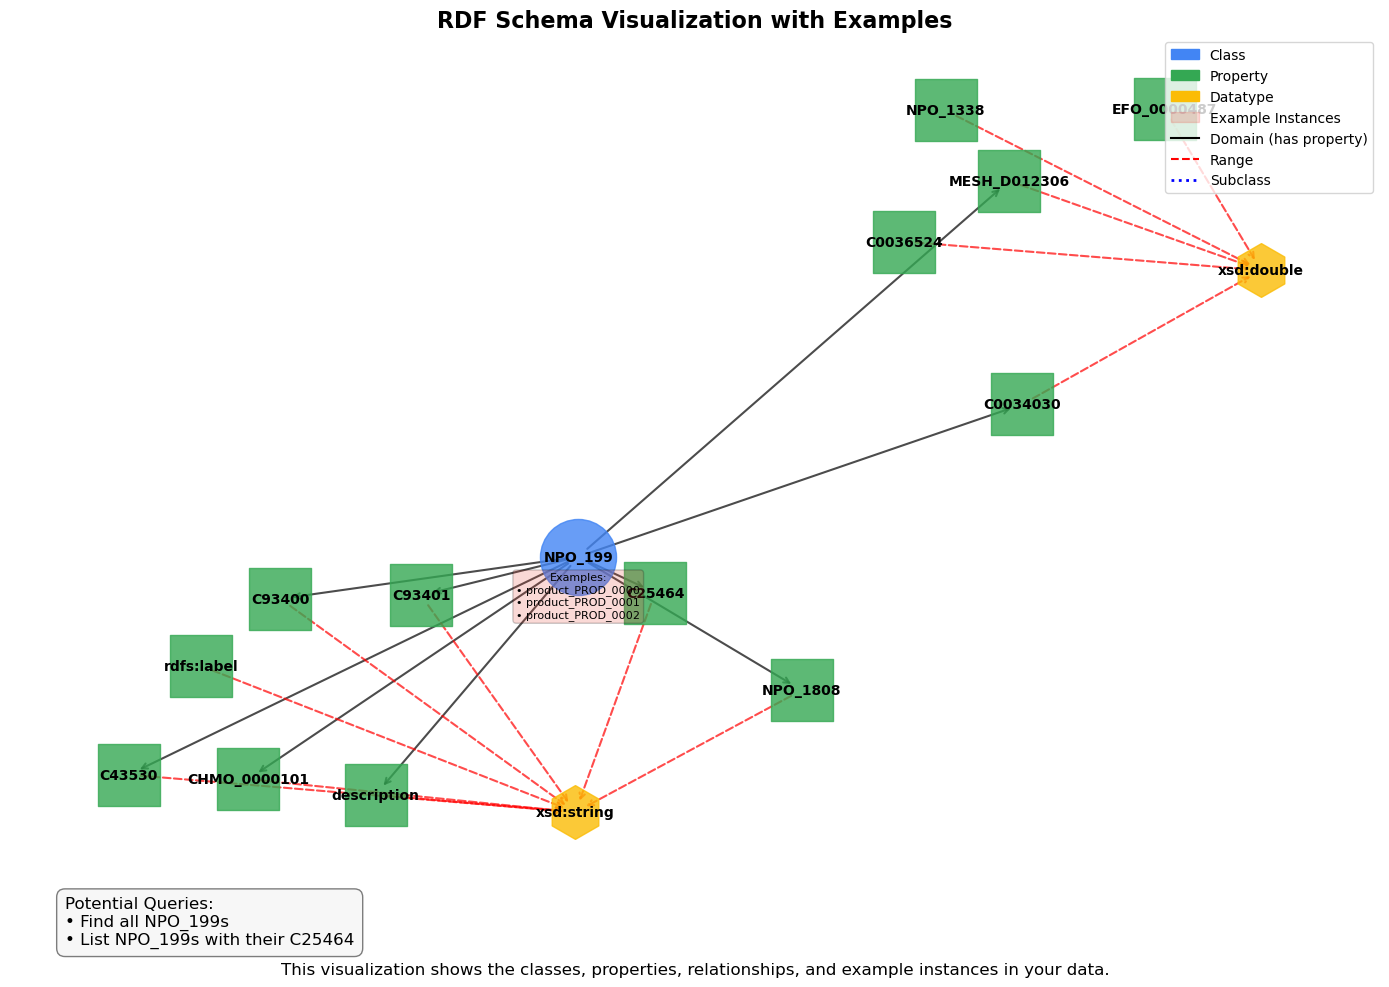

In [ ]:
import rdflib
from rdflib import Graph, Namespace, URIRef, Literal, BNode
from rdflib.namespace import RDF, RDFS, XSD, OWL
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.cm import get_cmap
import numpy as np
from collections import defaultdict, Counter
import textwrap
import tempfile
import os
import math
import community as community_louvain  # You'll need to install python-louvain package


def get_readable_label(uri, graph=None):
    """
    Create a readable label for a URI, using RDFS label if available
    
    Parameters:
    uri (rdflib.URIRef): The URI to get a label for
    graph (rdflib.Graph, optional): The graph to search for labels
    
    Returns:
    str: A readable label
    """
    if uri is None:
        return "None"
        
    uri_str = str(uri)
    
    # If we have a graph, check for rdfs:label
    if graph is not None:
        for _, _, label in graph.triples((uri, RDFS.label, None)):
            return str(label)
    
    # Try to extract from the URI
    # First, check for common namespaces
    if uri_str.startswith(str(XSD)):
        return f"xsd:{uri_str.split('#')[-1]}"
    elif uri_str.startswith(str(RDF)):
        return f"rdf:{uri_str.split('#')[-1]}"
    elif uri_str.startswith(str(RDFS)):
        return f"rdfs:{uri_str.split('#')[-1]}"
    elif uri_str.startswith(str(OWL)):
        return f"owl:{uri_str.split('#')[-1]}"
    
    # Otherwise, just extract the local name and format it nicely
    if '#' in uri_str:
        return uri_str.split('#')[-1]
    elif '/' in uri_str:
        return uri_str.split('/')[-1]
    else:
        return uri_str


def calculate_node_importance(G, classes, properties):
    """
    Calculate node importance based on centrality and node type
    
    Parameters:
    G (networkx.DiGraph): The graph
    classes (set): Set of class URIs
    properties (set): Set of property URIs
    
    Returns:
    dict: Dictionary of node importances
    """
    # Calculate centrality measures
    degree_centrality = nx.degree_centrality(G)
    betweenness_centrality = nx.betweenness_centrality(G)
    
    # Combine centrality measures and add node type weights
    importance = {}
    for node in G.nodes():
        # Base importance on centrality measures
        imp = 0.5 * degree_centrality.get(node, 0) + 0.5 * betweenness_centrality.get(node, 0)
        
        # Boost importance for classes and properties
        node_uri = URIRef(node) if not isinstance(node, str) else node
        if node_uri in classes:
            imp *= 1.5  # Classes are more important
        elif node_uri in properties:
            imp *= 1.2  # Properties are also important
            
        importance[node] = imp
        
    return importance


def detect_node_communities(G):
    """
    Detect communities in the graph for clustering
    
    Parameters:
    G (networkx.Graph): The graph (should be undirected)
    
    Returns:
    dict: Dictionary mapping nodes to community IDs
    """
    # Convert to undirected graph for community detection
    G_undirected = G.to_undirected()
    
    # Use Louvain method for community detection
    return community_louvain.best_partition(G_undirected)


def improved_spring_layout(G, node_importance, communities, k=None, iterations=50):
    """
    Custom force-directed layout with importance and community awareness
    
    Parameters:
    G (networkx.DiGraph): The graph
    node_importance (dict): Dictionary of node importances
    communities (dict): Dictionary mapping nodes to community IDs
    k (float, optional): Optimal distance between nodes
    iterations (int): Number of iterations
    
    Returns:
    dict: Dictionary of node positions
    """
    # If k is None, calculate based on graph size
    if k is None:
        # Use the formula: k = sqrt(area / number_of_nodes)
        k = 1.0 * math.sqrt(len(G.nodes))
    
    # Use spring layout as starting point
    pos = nx.spring_layout(G, k=k, iterations=iterations, seed=42)
    
    # Group nodes by community
    community_groups = defaultdict(list)
    for node, community_id in communities.items():
        if node in G.nodes():
            community_groups[community_id].append(node)
    
    # Calculate community centers
    community_centers = {}
    for community_id, nodes in community_groups.items():
        if nodes:
            x_coords = [pos[node][0] for node in nodes]
            y_coords = [pos[node][1] for node in nodes]
            community_centers[community_id] = (np.mean(x_coords), np.mean(y_coords))
    
    # Adjust positions to pull nodes toward their community center
    # and push important nodes outward for visibility
    new_pos = {}
    for node in G.nodes():
        if node in communities:
            community_id = communities[node]
            if community_id in community_centers:
                # Pull toward community center
                center_x, center_y = community_centers[community_id]
                current_x, current_y = pos[node]
                
                # Calculate pull factor based on importance
                imp = node_importance.get(node, 0.5)
                pull_factor = 0.3 * (1.0 - imp)  # Less pull for important nodes
                
                # Update position
                new_x = current_x + pull_factor * (center_x - current_x)
                new_y = current_y + pull_factor * (center_y - current_y)
                
                new_pos[node] = (new_x, new_y)
            else:
                new_pos[node] = pos[node]
        else:
            new_pos[node] = pos[node]
    
    # Scale positions to fill the available space
    min_x = min(x for x, _ in new_pos.values())
    max_x = max(x for x, _ in new_pos.values())
    min_y = min(y for _, y in new_pos.values())
    max_y = max(y for _, y in new_pos.values())
    
    scale_x = 1.8 / (max_x - min_x) if max_x > min_x else 1.0
    scale_y = 1.8 / (max_y - min_y) if max_y > min_y else 1.0
    
    for node in new_pos:
        x, y = new_pos[node]
        new_pos[node] = ((x - min_x) * scale_x - 0.9, (y - min_y) * scale_y - 0.9)
    
    return new_pos


def visualize_rdf_schema(schema_file, output_file='schema_visualization.png', format='turtle', 
                        show_node_clusters=True, node_spacing=1.5, iterations=100, dpi=300):
    """
    Generate an improved visualization of an RDF schema using NetworkX and Matplotlib.
    
    Parameters:
    schema_file (str): Path to the RDF schema file
    output_file (str): Path to save the visualization image
    format (str): Format of the RDF file (e.g., 'turtle', 'xml', 'json-ld')
    show_node_clusters (bool): Whether to use color-coded clusters for nodes
    node_spacing (float): Spacing factor between nodes (higher = more spacing)
    iterations (int): Number of iterations for layout algorithm
    dpi (int): DPI for the output image
    
    Returns:
    matplotlib.pyplot: The plot object for display in the notebook
    """
    # Load the RDF schema
    g = Graph()
    g.parse(schema_file, format=format)
    
    # Create a NetworkX graph
    G = nx.DiGraph()
    
    # Define colors for different node types
    class_color = "#4285F4"  # Blue for classes
    property_color = "#34A853"  # Green for properties
    datatype_color = "#FBBC05"  # Yellow for datatypes
    
    # Track namespace prefixes for cleaner labels
    namespaces = dict(g.namespaces())
    rev_namespaces = {str(uri): prefix for prefix, uri in namespaces.items()}
    
    # Extract classes
    classes = set()
    for s, p, o in g.triples((None, RDF.type, RDFS.Class)):
        classes.add(s)
        label = get_readable_label(s, g)
        G.add_node(str(s), label=label, type='class', color=class_color)
    
    for s, p, o in g.triples((None, RDF.type, OWL.Class)):
        classes.add(s)
        label = get_readable_label(s, g)
        G.add_node(str(s), label=label, type='class', color=class_color)
    
    # Extract properties
    properties = set()
    for s, p, o in g.triples((None, RDF.type, RDF.Property)):
        properties.add(s)
        label = get_readable_label(s, g)
        G.add_node(str(s), label=label, type='property', color=property_color)
    
    # Add datatype nodes that are used as ranges
    datatypes = set()
    for s, p, o in g.triples((None, RDFS.range, None)):
        if s in properties and (str(o).startswith(str(XSD)) or isinstance(o, URIRef)):
            datatypes.add(o)
            label = get_readable_label(o, g)
            G.add_node(str(o), label=label, type='datatype', color=datatype_color)
    
    # Add domain relationships (property -> class)
    for s, p, o in g.triples((None, RDFS.domain, None)):
        if s in properties and o in classes:
            G.add_edge(str(o), str(s), type='has_property')
    
    # Add range relationships (property -> class or datatype)
    for s, p, o in g.triples((None, RDFS.range, None)):
        if s in properties and (o in classes or o in datatypes):
            G.add_edge(str(s), str(o), type='has_range')
    
    # Add subclass relationships
    for s, p, o in g.triples((None, RDFS.subClassOf, None)):
        if s in classes and o in classes:
            G.add_edge(str(o), str(s), type='subclass')
    
    # If the graph is empty, add a message node
    if len(G.nodes) == 0:
        G.add_node("empty", label="No classes or properties found", type='message', color='#CCCCCC')
        
    # Calculate node importance based on centrality and type
    node_importance = calculate_node_importance(G, classes, properties)
    
    # Detect communities for node clustering
    communities = detect_node_communities(G)
    
    # Generate improved layout
    pos = improved_spring_layout(G, node_importance, communities, 
                               k=node_spacing, iterations=iterations)
    
    # Adjust figure size based on number of nodes
    node_count = len(G.nodes)
    if node_count > 100:
        figsize = (24, 18)
    elif node_count > 50:
        figsize = (20, 15)
    elif node_count > 20:
        figsize = (16, 12)
    else:
        figsize = (14, 10)
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Get community colors if clustering is enabled
    if show_node_clusters and len(G.nodes) > 5:
        # Get number of unique communities
        num_communities = len(set(communities.values()))
        # Generate a color map
        cmap = get_cmap('tab20' if num_communities <= 20 else 'viridis')
        community_colors = {comm_id: cmap(i/num_communities) for i, comm_id in enumerate(set(communities.values()))}
    
    # Draw nodes with different styles based on type
    class_nodes = [n for n, attr in G.nodes(data=True) if attr.get('type') == 'class']
    property_nodes = [n for n, attr in G.nodes(data=True) if attr.get('type') == 'property']
    datatype_nodes = [n for n, attr in G.nodes(data=True) if attr.get('type') == 'datatype']
    
    # Calculate node sizes based on importance
    class_sizes = [3000 + 2000 * node_importance.get(n, 0.5) for n in class_nodes]
    property_sizes = [2000 + 1000 * node_importance.get(n, 0.5) for n in property_nodes]
    datatype_sizes = [1500 + 500 * node_importance.get(n, 0.5) for n in datatype_nodes]
    
    # If clustering is enabled, use community colors
    if show_node_clusters and len(G.nodes) > 5:
        class_colors = [community_colors[communities.get(n, 0)] for n in class_nodes]
        property_colors = [community_colors[communities.get(n, 0)] for n in property_nodes]
        datatype_colors = [community_colors[communities.get(n, 0)] for n in datatype_nodes]
        
        # Draw nodes with community colors
        nx.draw_networkx_nodes(G, pos, nodelist=class_nodes, node_color=class_colors, 
                              node_size=class_sizes, alpha=0.8, node_shape='o', edgecolors='black', linewidths=1)
        nx.draw_networkx_nodes(G, pos, nodelist=property_nodes, node_color=property_colors, 
                              node_size=property_sizes, alpha=0.8, node_shape='s', edgecolors='black', linewidths=1)
        nx.draw_networkx_nodes(G, pos, nodelist=datatype_nodes, node_color=datatype_colors, 
                              node_size=datatype_sizes, alpha=0.8, node_shape='h', edgecolors='black', linewidths=1)
    else:
        # Draw nodes with original type-based colors
        nx.draw_networkx_nodes(G, pos, nodelist=class_nodes, node_color=class_color, 
                              node_size=class_sizes, alpha=0.8, node_shape='o')
        nx.draw_networkx_nodes(G, pos, nodelist=property_nodes, node_color=property_color, 
                              node_size=property_sizes, alpha=0.8, node_shape='s')
        nx.draw_networkx_nodes(G, pos, nodelist=datatype_nodes, node_color=datatype_color, 
                              node_size=datatype_sizes, alpha=0.8, node_shape='h')
    
    # Draw edges with different styles
    domain_edges = [(u, v) for u, v, attr in G.edges(data=True) if attr.get('type') == 'has_property']
    range_edges = [(u, v) for u, v, attr in G.edges(data=True) if attr.get('type') == 'has_range']
    subclass_edges = [(u, v) for u, v, attr in G.edges(data=True) if attr.get('type') == 'subclass']
    
    # Calculate edge widths based on node importance
    domain_widths = [1.5 + 1.0 * (node_importance.get(u, 0.5) + node_importance.get(v, 0.5))/2 for u, v in domain_edges]
    range_widths = [1.5 + 1.0 * (node_importance.get(u, 0.5) + node_importance.get(v, 0.5))/2 for u, v in range_edges]
    subclass_widths = [2.0 + 1.0 * (node_importance.get(u, 0.5) + node_importance.get(v, 0.5))/2 for u, v in subclass_edges]
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, edgelist=domain_edges, width=domain_widths, alpha=0.7, 
                          edge_color='black', style='solid', arrowstyle='->')
    nx.draw_networkx_edges(G, pos, edgelist=range_edges, width=range_widths, alpha=0.7, 
                          edge_color='red', style='dashed', arrowstyle='->')
    nx.draw_networkx_edges(G, pos, edgelist=subclass_edges, width=subclass_widths, alpha=0.7, 
                          edge_color='blue', style='dotted', arrowstyle='->')
    
    # Adjust label size based on graph complexity
    if node_count > 100:
        font_size = 8
    elif node_count > 50:
        font_size = 9
    elif node_count > 20:
        font_size = 10
    else:
        font_size = 11
    
    # Wrap labels for better display and limit length
    labels = {}
    for n, attr in G.nodes(data=True):
        label = attr['label']
        # Truncate very long labels
        if len(label) > 30:
            label = label[:27] + "..."
        # Adjust wrap width based on label length
        wrap_width = min(15, max(5, len(label) // 2))
        labels[n] = '\n'.join(textwrap.wrap(label, width=wrap_width))
    
    # Add labels with different styles
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=font_size, font_weight='bold')
    
    # Create legend elements
    legend_elements = [
        mpatches.Patch(color=class_color, label='Class'),
        mpatches.Patch(color=property_color, label='Property'),
        mpatches.Patch(color=datatype_color, label='Datatype'),
        Line2D([0], [0], color='black', lw=1.5, label='Domain (has property)'),
        Line2D([0], [0], color='red', lw=1.5, linestyle='--', label='Range'),
        Line2D([0], [0], color='blue', lw=2, linestyle=':', label='Subclass')
    ]
    
    # Add community colors to legend if clustering is enabled
    if show_node_clusters and len(G.nodes) > 5:
        comm_counts = Counter(communities.values())
        top_communities = sorted(comm_counts.items(), key=lambda x: x[1], reverse=True)[:5]  # Show top 5 communities
        
        for comm_id, count in top_communities:
            color = community_colors[comm_id]
            legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
                                         markersize=10, label=f'Cluster {comm_id} ({count} nodes)'))
    
    # Position legend based on graph size
    if node_count > 50:
        plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.01, 1))
    else:
        plt.legend(handles=legend_elements, loc='upper right')
    
    # Add a title and explanation
    plt.title('RDF Schema Visualization', fontsize=16, fontweight='bold')
    
    # Add graph statistics
    stats_text = (f"Schema Statistics: {len(classes)} classes, {len(properties)} properties, " 
                 f"{len(datatypes)} datatypes, {len(G.edges)} relationships")
    plt.figtext(0.5, 0.01, stats_text, horizontalalignment='center', fontsize=12)
    
    # Remove axis
    plt.axis('off')
    
    # Set tight layout with padding
    plt.tight_layout(pad=2.0, rect=[0, 0.02, 1, 0.98])
    
    # Save the figure with higher DPI for better detail
    plt.savefig(output_file, dpi=dpi, bbox_inches='tight')
    print(f"Schema visualization saved to {output_file}")
    
    # Count and report items found
    print(f"Found {len(classes)} classes, {len(properties)} properties, and {len(datatypes)} datatypes.")
    print(f"Visualization includes {len(G.nodes)} nodes and {len(G.edges)} edges.")
    
    # For very large graphs, add a note about DPI
    if node_count > 50:
        print(f"Note: For better details in this complex schema, the image was saved with {dpi} DPI.")
        print("You may need to zoom in to see all details clearly.")
    
    # Return the plot for display in notebooks
    return plt


def generate_schema_visualization_from_data(input_file, output_file='schema_vis.png', 
                                           input_format='turtle', include_samples=False,
                                           show_node_clusters=True, node_spacing=1.5, 
                                           iterations=100, dpi=300):
    """
    Wrapper function that extracts the schema from input data and visualizes it.
    
    Parameters:
    input_file (str): Path to the RDF data file
    output_file (str): Path to save the visualization image
    input_format (str): Format of the RDF file (e.g., 'turtle', 'xml', 'json-ld')
    include_samples (bool): Whether to include sample instance data in the visualization
    show_node_clusters (bool): Whether to use color-coded clusters for nodes
    node_spacing (float): Spacing factor between nodes (higher = more spacing)
    iterations (int): Number of iterations for layout algorithm
    dpi (int): DPI for the output image
    
    Returns:
    matplotlib.pyplot: The plot object for display in the notebook
    """
    # First, extract schema from the data
    data_graph = Graph()
    data_graph.parse(input_file, format=input_format)
    
    schema_graph = extract_schema_from_data(data_graph)
    
    # Save the schema to a temporary file
    with tempfile.NamedTemporaryFile(suffix='.ttl', delete=False) as tmp:
        schema_graph.serialize(destination=tmp.name, format='turtle')
        tmp_path = tmp.name
    
    try:
        # Visualize the schema (with or without samples)
        plt = visualize_rdf_schema(tmp_path, output_file, format='turtle',
                                  show_node_clusters=show_node_clusters, 
                                  node_spacing=node_spacing,
                                  iterations=iterations, dpi=dpi)
        
        # Clean up the temporary file
        os.unlink(tmp_path)
        
        return plt
    except Exception as e:
        # Clean up even if there's an error
        os.unlink(tmp_path)
        raise e


# Example usage
if __name__ == "__main__":
    # Basic visualization of a schema file
    # visualize_rdf_schema('schema.ttl', 'schema_visualization.png')
    
    # Generate and visualize schema from data
    # generate_schema_visualization_from_data('data.ttl', 'data_schema.png', 
    #                                        show_node_clusters=True, dpi=400)
    
    # For very large and complex schemas
    # generate_schema_visualization_from_data('large_data.ttl', 'complex_schema.png',
    #                                        node_spacing=2.0, iterations=200, dpi=600)
    pass

Loaded sample data from ./mappings/niosh_rdf_tutV2c.ttl
Schema visualization with samples saved to schema_vis.png
Found 31 classes, 47 properties, and 30 datatypes.
Included 93 example instances across 31 classes.
Visualization includes 79 nodes and 197 edges.


<module 'matplotlib.pyplot' from '/Users/pranavsingh/anaconda3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

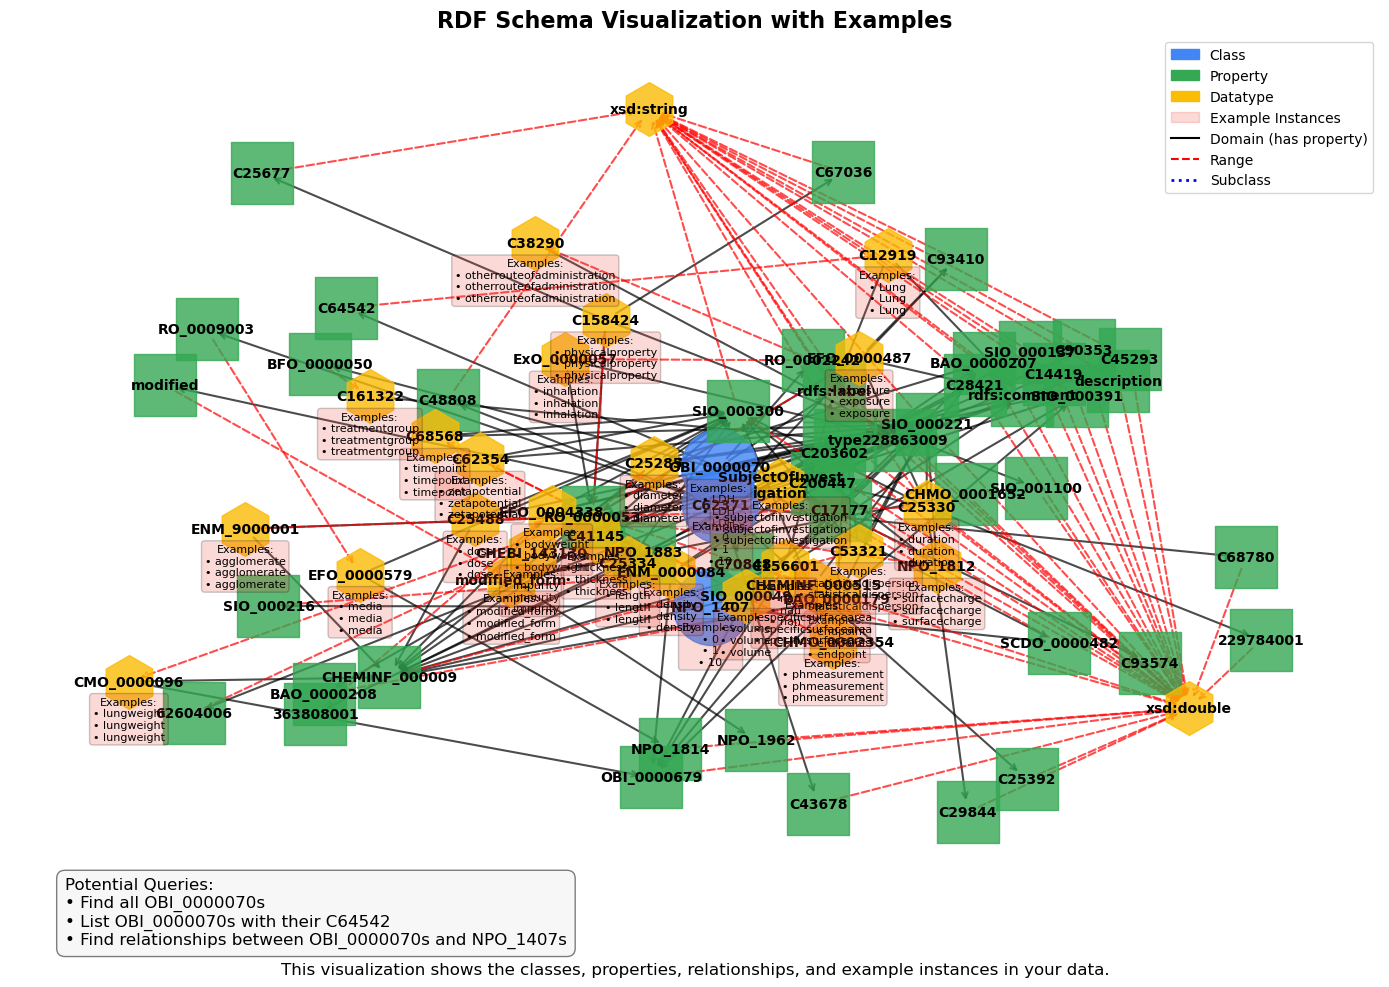

In [6]:
generate_schema_visualization_from_data('./mappings/niosh_rdf_tutV2c.ttl')
generate_schema_visualization_from_data('data.ttl', 'schema_viz_new.png', 
                                      show_node_clusters=True, dpi=400)

In [1]:
import rdflib
from rdflib import Graph, Namespace, URIRef, Literal, BNode
from rdflib.namespace import RDF, RDFS, XSD, OWL
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np
from collections import defaultdict
import textwrap
import tempfile
import os
import re

def get_readable_label(uri, graph=None):
    """
    Create a readable label for a URI, using RDFS label if available
    
    Parameters:
    uri (rdflib.URIRef): The URI to get a label for
    graph (rdflib.Graph, optional): The graph to search for labels
    
    Returns:
    str: A readable label
    """
    if uri is None:
        return "None"
    
    uri_str = str(uri)
    
    # If we have a graph, check for rdfs:label
    if graph is not None:
        for _, _, label in graph.triples((uri, RDFS.label, None)):
            return str(label)
    
    # Try to extract from the URI
    # Check for common namespaces first
    common_namespaces = {
        str(XSD): "xsd:",
        str(RDF): "rdf:",
        str(RDFS): "rdfs:",
        str(OWL): "owl:",
        "http://schema.org/": "schema:",
        "http://xmlns.com/foaf/0.1/": "foaf:",
        "http://purl.org/dc/elements/1.1/": "dc:",
        "http://purl.org/dc/terms/": "dcterms:",
    }
    
    for namespace, prefix in common_namespaces.items():
        if uri_str.startswith(namespace):
            return f"{prefix}{uri_str[len(namespace):]}"
    
    # Try to get a nice label from the URI itself
    if '#' in uri_str:
        local_name = uri_str.split('#')[-1]
    elif '/' in uri_str:
        local_name = uri_str.split('/')[-1]
    else:
        local_name = uri_str
    
    # Convert CamelCase to spaces
    local_name = re.sub(r'([a-z])([A-Z])', r'\1 \2', local_name)
    # Convert underscores to spaces
    local_name = local_name.replace('_', ' ')
    # Capitalize first letter
    if local_name:
        local_name = local_name[0].upper() + local_name[1:]
    
    return local_name

def extract_schema_from_data(data_graph):
    """
    Extract schema information from an RDF data graph
    
    Parameters:
    data_graph (rdflib.Graph): The loaded RDF data
    
    Returns:
    rdflib.Graph: A new graph containing schema information
    """
    schema_graph = Graph()
    
    # Copy namespace bindings
    for prefix, namespace in data_graph.namespaces():
        schema_graph.bind(prefix, namespace)
    
    # Ensure standard namespaces are bound
    schema_graph.bind('rdf', RDF)
    schema_graph.bind('rdfs', RDFS)
    schema_graph.bind('owl', OWL)
    schema_graph.bind('xsd', XSD)
    
    # Find classes (anything used as the object of an rdf:type statement)
    classes = set()
    for _, _, class_uri in data_graph.triples((None, RDF.type, None)):
        if isinstance(class_uri, URIRef):
            classes.add(class_uri)
            # Add class to schema
            schema_graph.add((class_uri, RDF.type, RDFS.Class))
    
    # Create property dictionary
    prop_domains = defaultdict(set)
    prop_ranges = defaultdict(set)
    
    # Find all properties and their domains/ranges
    for s, p, o in data_graph:
        if p != RDF.type:
            # For each property, find the classes of the subject (domain)
            for _, _, class_uri in data_graph.triples((s, RDF.type, None)):
                if class_uri in classes:
                    prop_domains[p].add(class_uri)
            
            # Try to determine range
            if isinstance(o, URIRef):
                # If object is a URI, check if it has a type
                for _, _, class_uri in data_graph.triples((o, RDF.type, None)):
                    if class_uri in classes:
                        prop_ranges[p].add(class_uri)
            elif isinstance(o, rdflib.Literal):
                # If object is a literal, use its datatype
                if o.datatype:
                    prop_ranges[p].add(o.datatype)
                else:
                    # Default to string for literals without explicit datatype
                    prop_ranges[p].add(XSD.string)
    
    # Add properties to schema
    for prop in set(prop_domains.keys()) | set(prop_ranges.keys()):
        schema_graph.add((prop, RDF.type, RDF.Property))
        
        # Add domains
        for domain in prop_domains[prop]:
            schema_graph.add((prop, RDFS.domain, domain))
        
        # Add ranges
        for range_uri in prop_ranges[prop]:
            schema_graph.add((prop, RDFS.range, range_uri))
    
    return schema_graph

def generate_example_queries(schema_g, sample_g=None, sample_instances=None):
    """
    Generate example SPARQL queries based on the schema and sample data
    
    Parameters:
    schema_g (rdflib.Graph): The RDF schema graph
    sample_g (rdflib.Graph, optional): Sample RDF data
    sample_instances (dict, optional): Dictionary mapping classes to instance examples
    
    Returns:
    list: List of example query strings
    """
    queries = []
    
    # Find all classes in the schema
    classes = set()
    for s, _, _ in schema_g.triples((None, RDF.type, RDFS.Class)):
        classes.add(s)
    for s, _, _ in schema_g.triples((None, RDF.type, OWL.Class)):
        classes.add(s)
    
    # If we have sample instances
    if sample_instances and len(sample_instances) > 0:
        classes_with_instances = list(sample_instances.keys())
        
        if classes_with_instances:
            # Example 1: Find instances of a specific class
            cls = classes_with_instances[0]
            cls_label = get_readable_label(cls, schema_g)
            queries.append(f"• Find all {cls_label}s")
            
            # Example 2: If we have properties, create a property query
            property_found = False
            for s, p, o in schema_g.triples((None, RDFS.domain, cls)):
                if (s, RDF.type, RDF.Property) in schema_g:
                    prop_label = get_readable_label(s, schema_g)
                    queries.append(f"• List {cls_label}s with their {prop_label}")
                    property_found = True
                    break
            
            if not property_found:
                queries.append(f"• List properties of each {cls_label}")
            
            # Example 3: If we have multiple classes, look for relationships
            if len(classes_with_instances) > 1:
                cls1 = classes_with_instances[0]
                cls2 = classes_with_instances[1]
                cls1_label = get_readable_label(cls1, schema_g)
                cls2_label = get_readable_label(cls2, schema_g)
                queries.append(f"• Find relationships between {cls1_label}s and {cls2_label}s")
    
    # If we couldn't generate specific queries or don't have sample data
    if len(queries) == 0:
        # Find a class to use in examples
        if classes:
            cls = next(iter(classes))
            cls_label = get_readable_label(cls, schema_g)
            queries.append(f"• Find all {cls_label}s")
            
            # Look for properties
            properties = set()
            for s, p, o in schema_g.triples((None, RDF.type, RDF.Property)):
                properties.add(s)
            
            if properties:
                prop = next(iter(properties))
                prop_label = get_readable_label(prop, schema_g)
                queries.append(f"• List entities with their {prop_label}")
                
                # Look for another class
                other_classes = classes - {cls}
                if other_classes:
                    other_cls = next(iter(other_classes))
                    other_cls_label = get_readable_label(other_cls, schema_g)
                    queries.append(f"• Find relationships between {cls_label}s and {other_cls_label}s")
                else:
                    queries.append(f"• Count the total number of {cls_label}s")
            else:
                queries.append(f"• List all properties of {cls_label}s")
                queries.append(f"• Count the total number of {cls_label}s")
        else:
            # Fallback to very generic queries
            queries = [
                "• Find all instances of a specific class",
                "• List properties related to a class",
                "• Find relationships between entities"
            ]
    
    return queries

def visualize_rdf_schema(schema_file, output_file='schema_visualization.png', format='turtle'):
    """
    Generate a visualization of an RDF schema using NetworkX and Matplotlib.
    
    Parameters:
    schema_file (str): Path to the RDF schema file
    output_file (str): Path to save the visualization image
    format (str): Format of the RDF file (e.g., 'turtle', 'xml', 'json-ld')
    
    Returns:
    matplotlib.pyplot: The plot object for display in the notebook
    """
    # Load the RDF schema
    g = Graph()
    g.parse(schema_file, format=format)
    
    # Create a NetworkX graph
    G = nx.DiGraph()
    
    # Define colors for different node types - using a more colorblind-friendly palette
    class_color = "#4285F4"  # Blue for classes
    property_color = "#34A853"  # Green for properties
    datatype_color = "#FBBC05"  # Yellow for datatypes
    
    # Track classes and properties for better organization
    classes = set()
    properties = set()
    datatypes = set()
    
    # Extract classes
    for s, p, o in g.triples((None, RDF.type, RDFS.Class)):
        classes.add(s)
        label = get_readable_label(s, g)
        G.add_node(str(s), label=label, type='class', color=class_color)
    
    for s, p, o in g.triples((None, RDF.type, OWL.Class)):
        classes.add(s)
        label = get_readable_label(s, g)
        G.add_node(str(s), label=label, type='class', color=class_color)
    
    # Extract properties
    for s, p, o in g.triples((None, RDF.type, RDF.Property)):
        properties.add(s)
        label = get_readable_label(s, g)
        G.add_node(str(s), label=label, type='property', color=property_color)
    
    # Add datatype nodes that are used as ranges
    for s, p, o in g.triples((None, RDFS.range, None)):
        if s in properties and (str(o).startswith(str(XSD)) or isinstance(o, URIRef)):
            datatypes.add(o)
            label = get_readable_label(o, g)
            G.add_node(str(o), label=label, type='datatype', color=datatype_color)
    
    # Add domain relationships (property -> class)
    for s, p, o in g.triples((None, RDFS.domain, None)):
        if s in properties and o in classes:
            G.add_edge(str(o), str(s), type='has_property')
    
    # Add range relationships (property -> class or datatype)
    for s, p, o in g.triples((None, RDFS.range, None)):
        if s in properties and (o in classes or o in datatypes):
            G.add_edge(str(s), str(o), type='has_range')
    
    # Add subclass relationships
    for s, p, o in g.triples((None, RDFS.subClassOf, None)):
        if s in classes and o in classes:
            G.add_edge(str(o), str(s), type='subclass')
    
    # If the graph is empty, add a message node
    if len(G.nodes) == 0:
        G.add_node("empty", label="No classes or properties found", type='message', color='#CCCCCC')
    
    # Create the plot
    plt.figure(figsize=(16, 12))
    
    # Use a hierarchical layout for clearer visualization of complex schemas
    # For small graphs, spring layout works well. For larger ones, try hierarchical layouts
    if len(G.nodes) < 15:
        pos = nx.spring_layout(G, k=1.0, iterations=50, seed=42)
    else:
        try:
            # Try to use a more structured layout for complex graphs
            pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
        except:
            # Fall back to spring layout with more spacing
            pos = nx.spring_layout(G, k=1.5, iterations=100, seed=42)
    
    # Draw nodes with different styles based on type
    class_nodes = [n for n, attr in G.nodes(data=True) if attr.get('type') == 'class']
    property_nodes = [n for n, attr in G.nodes(data=True) if attr.get('type') == 'property']
    datatype_nodes = [n for n, attr in G.nodes(data=True) if attr.get('type') == 'datatype']
    
    # Draw nodes with different sizes and shapes
    nx.draw_networkx_nodes(G, pos, nodelist=class_nodes, node_color=class_color, 
                          node_size=3500, alpha=0.8, node_shape='o', edgecolors='black')
    nx.draw_networkx_nodes(G, pos, nodelist=property_nodes, node_color=property_color, 
                          node_size=2500, alpha=0.8, node_shape='s', edgecolors='black')
    nx.draw_networkx_nodes(G, pos, nodelist=datatype_nodes, node_color=datatype_color, 
                          node_size=2000, alpha=0.8, node_shape='h', edgecolors='black')
    
    # Draw edges with different styles and clearly visible arrowheads
    domain_edges = [(u, v) for u, v, attr in G.edges(data=True) if attr.get('type') == 'has_property']
    range_edges = [(u, v) for u, v, attr in G.edges(data=True) if attr.get('type') == 'has_range']
    subclass_edges = [(u, v) for u, v, attr in G.edges(data=True) if attr.get('type') == 'subclass']
    
    nx.draw_networkx_edges(G, pos, edgelist=domain_edges, width=2.0, alpha=0.9, 
                          edge_color='black', style='solid', arrows=True, 
                          arrowstyle='->', arrowsize=20, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_edges(G, pos, edgelist=range_edges, width=2.0, alpha=0.9, 
                          edge_color='red', style='dashed', arrows=True,
                          arrowstyle='->', arrowsize=20, connectionstyle='arc3,rad=-0.1')
    nx.draw_networkx_edges(G, pos, edgelist=subclass_edges, width=2.5, alpha=0.9, 
                          edge_color='blue', style='dotted', arrows=True,
                          arrowstyle='->', arrowsize=20)
    
    # Wrap labels for better display
    labels = {}
    for n, attr in G.nodes(data=True):
        # Use smaller wrapping width for longer texts
        wrap_width = 15 if len(attr['label']) < 30 else 20
        labels[n] = '\n'.join(textwrap.wrap(attr['label'], width=wrap_width))
    
    # Add labels with white background for better readability
    for node, label in labels.items():
        x, y = pos[node]
        plt.text(x, y, label, fontsize=11, ha='center', va='center', 
                 bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9),
                 zorder=10)  # Higher zorder to ensure text is on top
    
    # Add a legend with clear descriptions
    legend_elements = [
        mpatches.Patch(color=class_color, label='Class (represents a type of entity)'),
        mpatches.Patch(color=property_color, label='Property (represents a relationship or attribute)'),
        mpatches.Patch(color=datatype_color, label='Datatype (represents a data value format)'),
        Line2D([0], [0], color='black', lw=2, label='Has Property (domain → property)'),
        Line2D([0], [0], color='red', lw=2, linestyle='--', label='Has Range (property → type)'),
        Line2D([0], [0], color='blue', lw=2.5, linestyle=':', label='Subclass (parent → child)')
    ]
    
    plt.legend(handles=legend_elements, loc='upper right', fontsize=12,
               title="Schema Components", title_fontsize=13,
               bbox_to_anchor=(1.1, 1), fancybox=True, shadow=True)
    
    # Add a title and explanation
    plt.title('RDF Schema Visualization', fontsize=18, fontweight='bold', pad=20)
    plt.figtext(0.5, 0.01, 'This visualization shows the structure of your data: the classes (blue), properties (green),\nand relationships between them.', 
             horizontalalignment='center', fontsize=13, bbox=dict(facecolor='#f5f5f5', alpha=0.5))
    
    # Remove axis
    plt.axis('off')
    
    # Add potential queries explanation
    example_queries = generate_example_queries(g)
    query_text = "Example Queries You Can Run:\n" + "\n".join(example_queries)
    plt.figtext(0.02, 0.02, query_text, fontsize=12, 
                bbox=dict(facecolor='#f0f0f0', alpha=0.7, boxstyle='round,pad=0.8'))
    
    # Count nodes by type for statistics
    stats_text = f"Schema Statistics:\n• {len(classes)} Classes\n• {len(properties)} Properties\n• {len(datatypes)} Datatypes"
    plt.figtext(0.02, 0.92, stats_text, fontsize=12,
                bbox=dict(facecolor='#f0f0f0', alpha=0.7, boxstyle='round,pad=0.8'))
    
    # Save the figure with high quality
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])  # Adjust layout to make room for title and footer
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Schema visualization saved to {output_file}")
    
    # Return the plot for display in notebooks
    return plt

def visualize_rdf_schema_with_samples(schema_file, sample_file, output_file='schema_with_samples.png', format='turtle'):
    """
    Generate a visualization of an RDF schema using NetworkX and Matplotlib.
    Includes examples from a sample RDF data file.
    
    Parameters:
    schema_file (str): Path to the RDF schema file
    sample_file (str): Path to a sample RDF data file
    output_file (str): Path to save the visualization image
    format (str): Format of the RDF file (e.g., 'turtle', 'xml', 'json-ld')
    
    Returns:
    matplotlib.pyplot: The plot object for display in the notebook
    """
    # Load the RDF schema
    g = Graph()
    g.parse(schema_file, format=format)
    
    # Create a NetworkX graph
    G = nx.DiGraph()
    
    # Define colors for different node types - using a more colorblind-friendly palette
    class_color = "#4285F4"  # Blue for classes
    property_color = "#34A853"  # Green for properties
    datatype_color = "#FBBC05"  # Yellow for datatypes
    example_color = "#EA4335"   # Red for sample instances
    
    # Track classes and properties for better organization
    classes = set()
    properties = set()
    datatypes = set()
    
    # Extract classes
    for s, p, o in g.triples((None, RDF.type, RDFS.Class)):
        classes.add(s)
        label = get_readable_label(s, g)
        G.add_node(str(s), label=label, type='class', color=class_color)
    
    for s, p, o in g.triples((None, RDF.type, OWL.Class)):
        classes.add(s)
        label = get_readable_label(s, g)
        G.add_node(str(s), label=label, type='class', color=class_color)
    
    # Extract properties
    for s, p, o in g.triples((None, RDF.type, RDF.Property)):
        properties.add(s)
        label = get_readable_label(s, g)
        G.add_node(str(s), label=label, type='property', color=property_color)
    
    # Add datatype nodes that are used as ranges
    for s, p, o in g.triples((None, RDFS.range, None)):
        if s in properties and (str(o).startswith(str(XSD)) or isinstance(o, URIRef)):
            datatypes.add(o)
            label = get_readable_label(o, g)
            G.add_node(str(o), label=label, type='datatype', color=datatype_color)
    
    # Add domain relationships (property -> class)
    for s, p, o in g.triples((None, RDFS.domain, None)):
        if s in properties and o in classes:
            G.add_edge(str(o), str(s), type='has_property')
    
    # Add range relationships (property -> class or datatype)
    for s, p, o in g.triples((None, RDFS.range, None)):
        if s in properties and (o in classes or o in datatypes):
            G.add_edge(str(s), str(o), type='has_range')
    
    # Add subclass relationships
    for s, p, o in g.triples((None, RDFS.subClassOf, None)):
        if s in classes and o in classes:
            G.add_edge(str(o), str(s), type='subclass')
    
    # Load sample data
    sample_instances = {}
    try:
        sample_g = Graph()
        sample_g.parse(sample_file, format=format)
        print(f"Loaded sample data from {sample_file}")
        
        # Extract example instances for each class
        for s, p, o in sample_g.triples((None, RDF.type, None)):
            if isinstance(o, URIRef) and o in classes:
                if o not in sample_instances:
                    sample_instances[o] = []
                
                # Get a label for the instance if available
                instance_label = None
                for _, _, label in sample_g.triples((s, RDFS.label, None)):
                    instance_label = str(label)
                    break
                    
                if not instance_label:
                    # Try to find a name or title property
                    for name_prop in [
                        URIRef("http://xmlns.com/foaf/0.1/name"),
                        URIRef("http://purl.org/dc/elements/1.1/title"),
                        URIRef("http://schema.org/name")
                    ]:
                        for _, _, name in sample_g.triples((s, name_prop, None)):
                            instance_label = str(name)
                            break
                        if instance_label:
                            break
                
                if not instance_label:
                    instance_label = get_readable_label(s)
                
                sample_instances[o].append(instance_label)
                if len(sample_instances[o]) >= 3:  # Limit to 3 examples per class
                    sample_instances[o] = sample_instances[o][:3]
    
    except Exception as e:
        print(f"Error loading sample data: {e}")
        sample_g = None
        sample_instances = {}
    
    # If the graph is empty, add a message node
    if len(G.nodes) == 0:
        G.add_node("empty", label="No classes or properties found", type='message', color='#CCCCCC')
    
    # Create the plot
    plt.figure(figsize=(16, 12))
    
    # Use appropriate layout based on graph size
    if len(G.nodes) < 15:
        pos = nx.spring_layout(G, k=1.0, iterations=50, seed=42)
    else:
        try:
            # Try to use a more structured layout for complex graphs
            pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
        except:
            # Fall back to spring layout with more spacing
            pos = nx.spring_layout(G, k=1.5, iterations=100, seed=42)
    
    # Draw nodes with different styles based on type
    class_nodes = [n for n, attr in G.nodes(data=True) if attr.get('type') == 'class']
    property_nodes = [n for n, attr in G.nodes(data=True) if attr.get('type') == 'property']
    datatype_nodes = [n for n, attr in G.nodes(data=True) if attr.get('type') == 'datatype']
    
    # Draw nodes with different sizes and shapes
    nx.draw_networkx_nodes(G, pos, nodelist=class_nodes, node_color=class_color, 
                          node_size=3500, alpha=0.8, node_shape='o', edgecolors='black')
    nx.draw_networkx_nodes(G, pos, nodelist=property_nodes, node_color=property_color, 
                          node_size=2500, alpha=0.8, node_shape='s', edgecolors='black')
    nx.draw_networkx_nodes(G, pos, nodelist=datatype_nodes, node_color=datatype_color, 
                          node_size=2000, alpha=0.8, node_shape='h', edgecolors='black')
    
    # Draw edges with different styles and clearly visible arrowheads
    domain_edges = [(u, v) for u, v, attr in G.edges(data=True) if attr.get('type') == 'has_property']
    range_edges = [(u, v) for u, v, attr in G.edges(data=True) if attr.get('type') == 'has_range']
    subclass_edges = [(u, v) for u, v, attr in G.edges(data=True) if attr.get('type') == 'subclass']
    
    nx.draw_networkx_edges(G, pos, edgelist=domain_edges, width=2.0, alpha=0.9, 
                          edge_color='black', style='solid', arrows=True, 
                          arrowstyle='->', arrowsize=20, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_edges(G, pos, edgelist=range_edges, width=2.0, alpha=0.9, 
                          edge_color='red', style='dashed', arrows=True,
                          arrowstyle='->', arrowsize=20, connectionstyle='arc3,rad=-0.1')
    nx.draw_networkx_edges(G, pos, edgelist=subclass_edges, width=2.5, alpha=0.9, 
                          edge_color='blue', style='dotted', arrows=True,
                          arrowstyle='->', arrowsize=20)
    
    # Wrap labels for better display
    labels = {}
    for n, attr in G.nodes(data=True):
        # Use smaller wrapping width for longer texts
        wrap_width = 15 if len(attr['label']) < 30 else 20
        labels[n] = '\n'.join(textwrap.wrap(attr['label'], width=wrap_width))
    
    # Add labels with white background for better readability
    for node, label in labels.items():
        x, y = pos[node]
        plt.text(x, y, label, fontsize=11, ha='center', va='center', 
                 bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9),
                 zorder=10)  # Higher zorder to ensure text is on top
    
    # Add example instances to the visualization with better formatting
    if sample_instances:
        for cls, instances in sample_instances.items():
            if len(instances) > 0:
                examples_text = "Examples:\n• " + "\n• ".join(instances)
                if str(cls) in G.nodes:
                    cls_pos = pos[str(cls)]
                    # Calculate offset for examples, moving them below the class
                    offset_y = -0.15
                    # Add example text with background
                    plt.annotate(examples_text, 
                                xy=cls_pos, 
                                xytext=(cls_pos[0], cls_pos[1] + offset_y),
                                bbox=dict(boxstyle="round,pad=0.5", 
                                          fc=example_color, ec="darkred", alpha=0.2),
                                ha='center', fontsize=10, weight='bold',
                                zorder=5)  # Lower zorder than labels but above edges
    
    # Add a legend with clear descriptions
    legend_elements = [
        mpatches.Patch(color=class_color, label='Class (represents a type of entity)'),
        mpatches.Patch(color=property_color, label='Property (represents a relationship or attribute)'),
        mpatches.Patch(color=datatype_color, label='Datatype (represents a data value format)'),
        mpatches.Patch(color=example_color, alpha=0.2, ec="darkred", label='Example Instances (real data examples)'),
        Line2D([0], [0], color='black', lw=2, label='Has Property (domain → property)'),
        Line2D([0], [0], color='red', lw=2, linestyle='--', label='Has Range (property → type)'),
        Line2D([0], [0], color='blue', lw=2.5, linestyle=':', label='Subclass (parent → child)')
    ]
    
    plt.legend(handles=legend_elements, loc='upper right', fontsize=12,
               title="Schema Components", title_fontsize=13,
               bbox_to_anchor=(1.1, 1), fancybox=True, shadow=True)
    
    # Add a title and explanation
    plt.title('RDF Schema Visualization with Examples', fontsize=18, fontweight='bold', pad=20)
    plt.figtext(0.5, 0.01, 'This visualization shows the structure of your data: classes (blue), properties (green),\ndata types (yellow), and example instances from your dataset (red boxes).', 
             horizontalalignment='center', fontsize=13, bbox=dict(facecolor='#f5f5f5', alpha=0.5))
    
    # Remove axis
    plt.axis('off')
    
    # Add potential queries explanation based on sample data
    if sample_g:
        example_queries = generate_example_queries(g, sample_g, sample_instances)
    else:
        example_queries = generate_example_queries(g)
        
    query_text = "Example Queries You Can Run:\n" + "\n".join(example_queries)
    plt.figtext(0.02, 0.02, query_text, fontsize=12, 
                bbox=dict(facecolor='#f0f0f0', alpha=0.7, boxstyle='round,pad=0.8'))
    
    # Count nodes by type for statistics
    stats_text = f"Schema Statistics:\n• {len(classes)} Classes\n• {len(properties)} Properties\n• {len(datatypes)} Datatypes"
    if sample_instances:
        instance_count = sum(len(instances) for instances in sample_instances.values())
        stats_text += f"\n• {instance_count} Example Instances across {len(sample_instances)} classes"
    
    plt.figtext(0.02, 0.92, stats_text, fontsize=12,
                bbox=dict(facecolor='#f0f0f0', alpha=0.7, boxstyle='round,pad=0.8'))
    
    # Save the figure with high quality
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])  # Adjust layout to make room for title and footer
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Schema visualization with samples saved to {output_file}")
    
    # Return the plot for display in notebooks
    return plt

def generate_schema_visualization_from_data(input_file, output_file='schema_vis.png', input_format='turtle', include_samples=True):
    """
    Wrapper function that extracts the schema from input data and visualizes it.
    
    Parameters:
    input_file (str): Path to the RDF data file
    output_file (str): Path to save the visualization image
    input_format (str): Format of the RDF file (e.g., 'turtle', 'xml', 'json-ld')
    include_samples (bool): Whether to include sample instance data in the visualization
    
    Returns:
    matplotlib.pyplot: The plot object for display in the notebook
    """
    # First, extract schema from the data
    data_graph = Graph()
    data_graph.parse(input_file, format=input_format)
    
    schema_graph = extract_schema_from_data(data_graph)
    
    # Save the schema to a temporary file
    with tempfile.NamedTemporaryFile(suffix='.ttl', delete=False) as tmp:
        schema_graph.serialize(destination=tmp.name, format='turtle')
        tmp_path = tmp.name
    
    try:
        # Visualize the schema (with or without samples)
        if include_samples:
            plt = visualize_rdf_schema_with_samples(tmp_path, input_file, output_file, format='turtle')
        else:
            plt = visualize_rdf_schema(tmp_path, output_file, format='turtle')
        
        # Clean up the temporary file
        os.unlink(tmp_path)
        
        return plt
    except Exception as e:
        # Clean up even if there's an error
        os.unlink(tmp_path)
        raise e

def visualize_complex_rdf_schema(input_file, output_file='schema_vis.png', input_format='turtle', max_nodes=25):
    """
    Visualize a complex RDF schema with intelligent handling of large schemas.
    For very large schemas, this visualizes core components and provides statistics
    about the full schema.
    
    Parameters:
    input_file (str): Path to the RDF data/schema file
    output_file (str): Path to save the visualization image
    input_format (str): Format of the RDF file (e.g., 'turtle', 'xml', 'json-ld')
    max_nodes (int): Maximum number of nodes to show in visualization
    
    Returns:
    matplotlib.pyplot: The plot object for display in the notebook
    """
    # Load the graph
    full_graph = Graph()
    full_graph.parse(input_file, format=input_format)
    
    # Extract schema if this is a data file
    schema_graph = extract_schema_from_data(full_graph)
    
    # Count total classes, properties, and datatypes
    classes = set()
    properties = set()
    datatypes = set()
    
    for s, p, o in schema_graph.triples((None, RDF.type, RDFS.Class)):
        classes.add(s)
    for s, p, o in schema_graph.triples((None, RDF.type, OWL.Class)):
        classes.add(s)
    for s, p, o in schema_graph.triples((None, RDF.type, RDF.Property)):
        properties.add(s)
    # Find datatypes in ranges
    for s, p, o in schema_graph.triples((None, RDFS.range, None)):
        if str(o).startswith(str(XSD)) or isinstance(o, URIRef):
            datatypes.add(o)
    
    total_nodes = len(classes) + len(properties) + len(datatypes)
    print(f"Full schema contains {len(classes)} classes, {len(properties)} properties, and {len(datatypes)} datatypes.")
    
    # If schema is reasonably sized, just visualize normally
    if total_nodes <= max_nodes:
        return generate_schema_visualization_from_data(input_file, output_file, input_format)
    
    # For large schemas, create a simplified view focusing on most important elements
    print(f"Schema is complex ({total_nodes} elements). Creating simplified visualization of core components.")
    
    # Create a new graph for the core schema
    core_schema = Graph()
    
    # Copy namespace bindings
    for prefix, namespace in schema_graph.namespaces():
        core_schema.bind(prefix, namespace)
    
    # Find most connected classes (those with the most properties)
    class_connections = defaultdict(int)
    for s, p, o in schema_graph.triples((None, RDFS.domain, None)):
        class_connections[o] += 1
    
    # Sort classes by number of properties
    sorted_classes = sorted(class_connections.items(), key=lambda x: x[1], reverse=True)
    
    # Take top classes up to a limit
    top_classes = set()
    properties_to_include = set()
    
    # Include top 30% of classes or at least 5, whichever is larger
    num_top_classes = max(5, int(len(classes) * 0.3))
    num_top_classes = min(num_top_classes, 15)  # Cap at 15 classes
    
    for cls, _ in sorted_classes[:num_top_classes]:
        if cls in classes:
            top_classes.add(cls)
            # Add this class to the core schema
            core_schema.add((cls, RDF.type, RDFS.Class))
            
            # Find properties that have this class as domain
            for prop, _, _ in schema_graph.triples((None, RDFS.domain, cls)):
                properties_to_include.add(prop)
                core_schema.add((prop, RDF.type, RDF.Property))
                core_schema.add((prop, RDFS.domain, cls))
                
                # Also include the range information for these properties
                for _, _, range_cls in schema_graph.triples((prop, RDFS.range, None)):
                    core_schema.add((prop, RDFS.range, range_cls))
                    
                    # If range is a class, include it too
                    if range_cls in classes:
                        top_classes.add(range_cls)
                        core_schema.add((range_cls, RDF.type, RDFS.Class))
    
    # Add subclass relationships between included classes
    for parent, _, child in schema_graph.triples((None, RDFS.subClassOf, None)):
        if parent in top_classes and child in top_classes:
            core_schema.add((parent, RDFS.subClassOf, child))
    
    # Save the core schema to a temporary file
    with tempfile.NamedTemporaryFile(suffix='.ttl', delete=False) as tmp:
        core_schema.serialize(destination=tmp.name, format='turtle')
        tmp_path = tmp.name
    
    try:
        # Create the visualization
        plt.figure(figsize=(16, 12))
        
        # Visualize the core schema
        core_plt = visualize_rdf_schema(tmp_path, output_file, format='turtle')
        
        # Add a special title indicating this is a simplified view
        plt.suptitle(f'Simplified Core Schema (showing {len(top_classes)} out of {len(classes)} classes)', 
                    fontsize=18, fontweight='bold', color='darkred', y=0.98)
        
        # Add stats about what's not shown
        hidden_stats = (f"Not shown: {len(classes) - len(top_classes)} classes, "
                      f"{len(properties) - len(properties_to_include)} properties\n"
                      f"Full schema contains {total_nodes} total elements")
        
        plt.figtext(0.5, 0.005, hidden_stats, ha='center', fontsize=12, 
                   bbox=dict(facecolor='lightyellow', alpha=0.8, boxstyle='round,pad=0.5'))
        
        # Save with the modified titles
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Simplified core schema visualization saved to {output_file}")
        
        # Clean up temp file
        os.unlink(tmp_path)
        
        return plt
    except Exception as e:
        # Clean up even if there's an error
        os.unlink(tmp_path)
        raise e

Loaded sample data from ./mappings/cpsc_database.ttl
Schema visualization with samples saved to cpscschema.png


<module 'matplotlib.pyplot' from '/Users/pranavsingh/anaconda3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

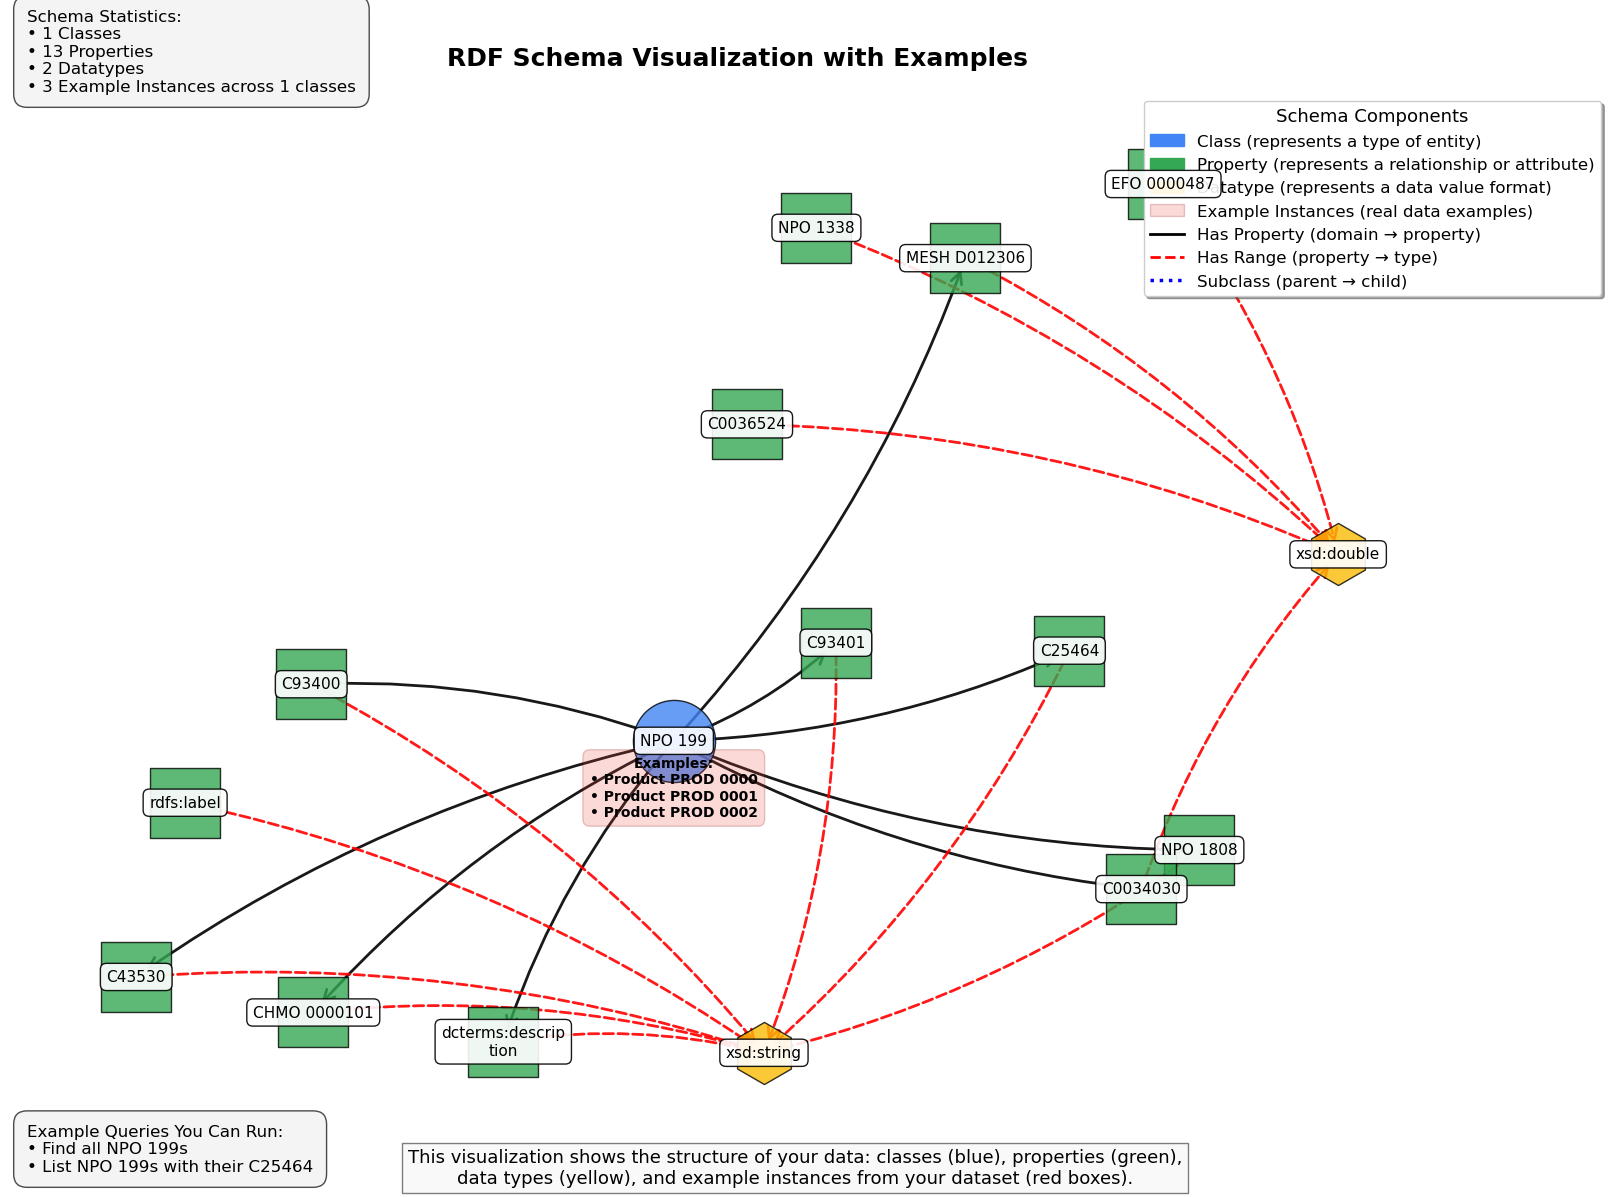

In [2]:
# Usage Examples for RDF Schema Visualization

# Extract schema from data and visualize it
generate_schema_visualization_from_data('./mappings/cpsc_database.ttl', output_file='cpscschema.png')


Full schema contains 31 classes, 47 properties, and 30 datatypes.
Schema is complex (108 elements). Creating simplified visualization of core components.
Schema visualization saved to complex_schema.png
Simplified core schema visualization saved to complex_schema.png


<module 'matplotlib.pyplot' from '/Users/pranavsingh/anaconda3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

<Figure size 1600x1200 with 0 Axes>

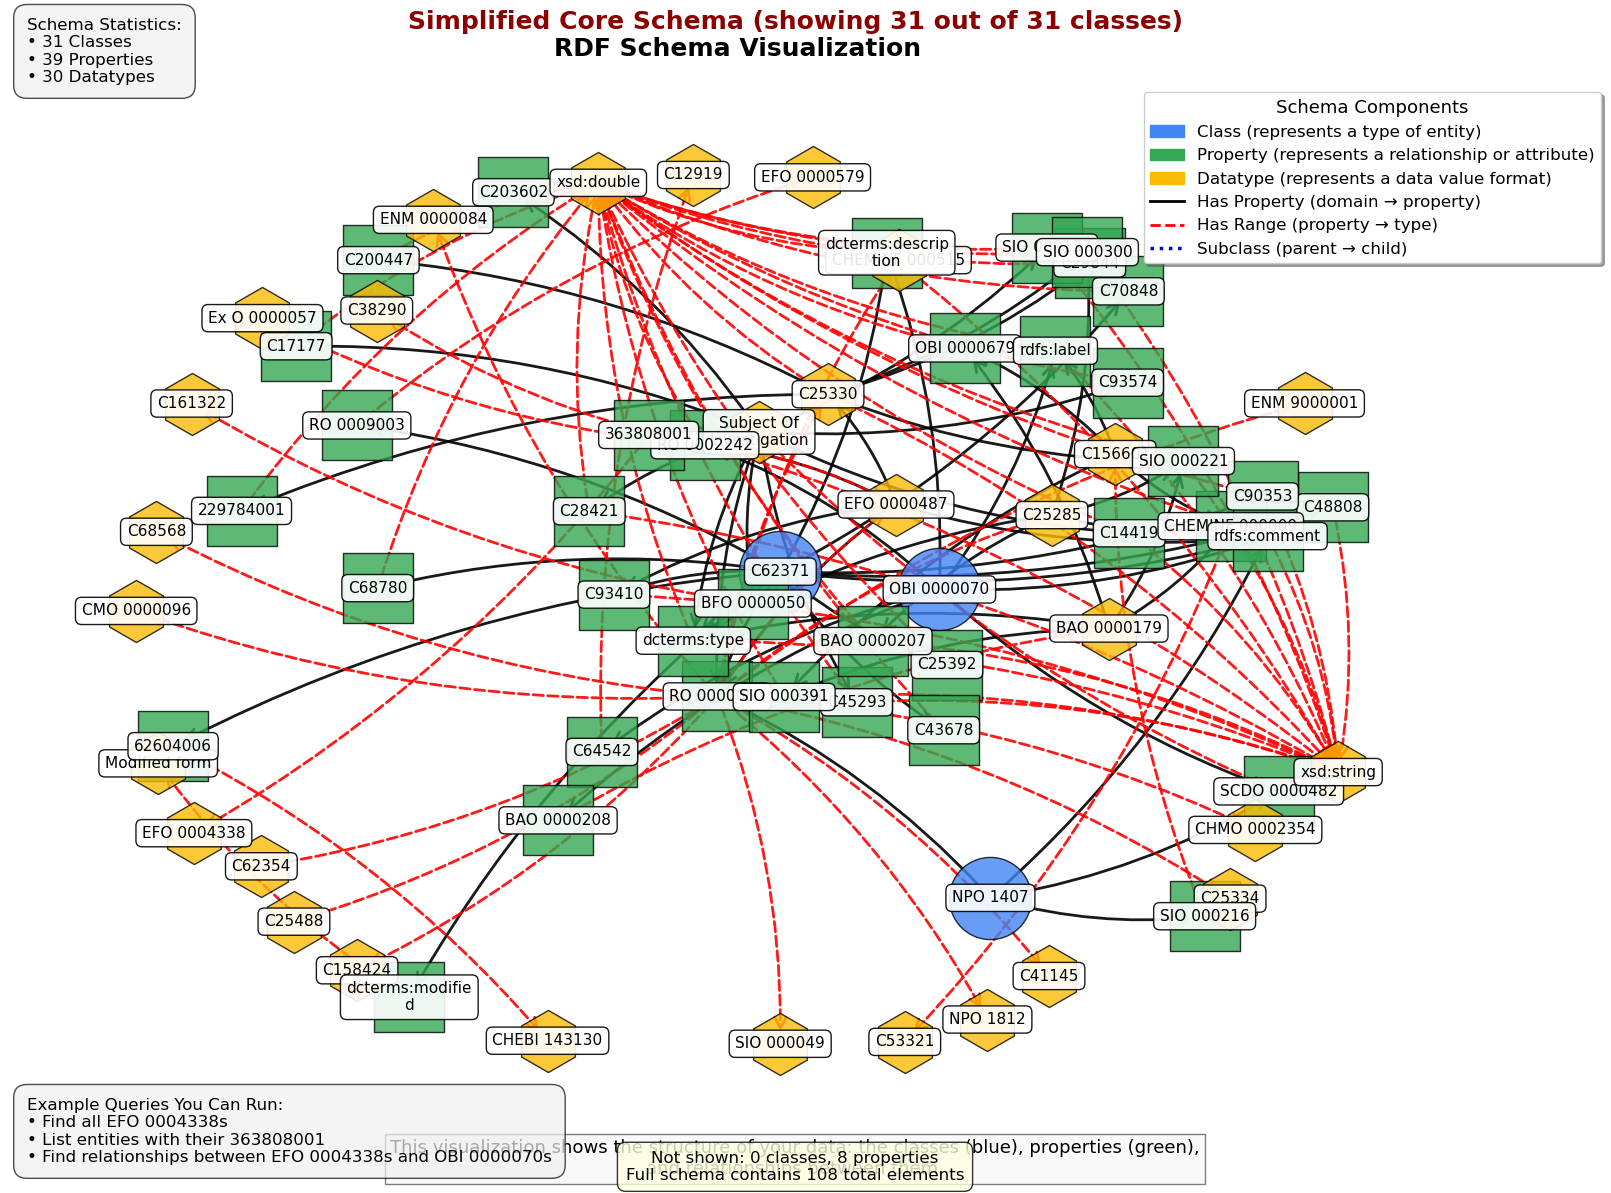

In [3]:
visualize_complex_rdf_schema('./mappings/niosh_rdf_tutV2c.ttl', output_file='complex_schema.png')

In [ ]:
# Visualize a complex schema (automatically handles large schemas)
visualize_complex_rdf_schema('./mappings/niosh_rdf_tutV2c.ttl', output_file='complex_schema.png')

# Example usage in a data exploration workflow:
import rdflib
from rdflib import Graph

# 1. Load and examine your RDF data
g = Graph()
g.parse('my_data.ttl', format='turtle')
print(f"Loaded {len(g)} triples from data file")

# 2. Extract and save the schema
schema_g = extract_schema_from_data(g)
schema_g.serialize(destination='extracted_schema.ttl', format='turtle')
print(f"Extracted schema with {len(schema_g)} triples")

# 3. Visualize the schema
visualize_rdf_schema('extracted_schema.ttl', output_file='my_schema_viz.png')

# 4. For large datasets, use a specialized visualization
if len(schema_g) > 100:
    visualize_complex_rdf_schema('extracted_schema.ttl', 
                               output_file='complex_schema_viz.png', 
                               max_nodes=40)  # Adjust max_nodes based on desired detail level

In [12]:
import rdflib
from rdflib import Graph, Namespace, URIRef, Literal, BNode
from rdflib.namespace import RDF, RDFS, XSD, OWL
from collections import defaultdict
import textwrap
import re
import os
from datetime import datetime

def get_readable_label(uri, graph=None):
    """
    Create a readable label for a URI, using RDFS label if available
    
    Parameters:
    uri (rdflib.URIRef): The URI to get a label for
    graph (rdflib.Graph, optional): The graph to search for labels
    
    Returns:
    str: A readable label
    """
    if uri is None:
        return "None"
    
    uri_str = str(uri)
    
    # If we have a graph, check for rdfs:label
    if graph is not None:
        for _, _, label in graph.triples((uri, RDFS.label, None)):
            return str(label)
    
    # Try to extract from the URI
    # Check for common namespaces first
    common_namespaces = {
        str(XSD): "xsd:",
        str(RDF): "rdf:",
        str(RDFS): "rdfs:",
        str(OWL): "owl:",
        "http://schema.org/": "schema:",
        "http://xmlns.com/foaf/0.1/": "foaf:",
        "http://purl.org/dc/elements/1.1/": "dc:",
        "http://purl.org/dc/terms/": "dcterms:",
    }
    
    for namespace, prefix in common_namespaces.items():
        if uri_str.startswith(namespace):
            return f"{prefix}{uri_str[len(namespace):]}"
    
    # Try to get a nice label from the URI itself
    if '#' in uri_str:
        local_name = uri_str.split('#')[-1]
    elif '/' in uri_str:
        local_name = uri_str.split('/')[-1]
    else:
        local_name = uri_str
    
    # Convert CamelCase to spaces
    local_name = re.sub(r'([a-z])([A-Z])', r'\1 \2', local_name)
    # Convert underscores to spaces
    local_name = local_name.replace('_', ' ')
    # Capitalize first letter
    if local_name:
        local_name = local_name[0].upper() + local_name[1:]
    
    return local_name

def get_namespace_info(graph):
    """
    Extract and organize namespace information from the graph
    
    Parameters:
    graph (rdflib.Graph): The RDF graph
    
    Returns:
    dict: A dictionary mapping prefix to namespace URI
    """
    namespace_info = {}
    
    for prefix, namespace in graph.namespaces():
        namespace_info[prefix] = str(namespace)
    
    return namespace_info

def get_description(uri, graph):
    """
    Get description, comment or other documentation for a URI
    
    Parameters:
    uri (rdflib.URIRef): The URI to get description for
    graph (rdflib.Graph): The RDF graph
    
    Returns:
    str: A description or empty string if none found
    """
    # Check for rdfs:comment
    for _, _, comment in graph.triples((uri, RDFS.comment, None)):
        return str(comment)
    
    # Check for other common description properties
    description_properties = [
        RDFS.comment,
        URIRef("http://purl.org/dc/elements/1.1/description"),
        URIRef("http://purl.org/dc/terms/description"),
        URIRef("http://schema.org/description"),
        URIRef("http://www.w3.org/2004/02/skos/core#definition")
    ]
    
    for prop in description_properties:
        for _, _, desc in graph.triples((uri, prop, None)):
            return str(desc)
    
    return ""

def get_property_details(prop, graph):
    """
    Get detailed information about a property
    
    Parameters:
    prop (rdflib.URIRef): The property URI
    graph (rdflib.Graph): The RDF graph
    
    Returns:
    dict: A dictionary with property details
    """
    details = {
        'uri': str(prop),
        'label': get_readable_label(prop, graph),
        'description': get_description(prop, graph),
        'domains': [],
        'ranges': [],
        'super_properties': [],
        'type': 'Property'
    }
    
    # Get domains (what classes can have this property)
    for _, _, domain in graph.triples((prop, RDFS.domain, None)):
        details['domains'].append({
            'uri': str(domain),
            'label': get_readable_label(domain, graph)
        })
    
    # Get ranges (what values this property can have)
    for _, _, range_uri in graph.triples((prop, RDFS.range, None)):
        details['ranges'].append({
            'uri': str(range_uri),
            'label': get_readable_label(range_uri, graph)
        })
    
    # Get super-properties
    for _, _, super_prop in graph.triples((prop, RDFS.subPropertyOf, None)):
        details['super_properties'].append({
            'uri': str(super_prop),
            'label': get_readable_label(super_prop, graph)
        })
    
    # Check if it's a datatype property or object property
    is_datatype_prop = False
    for range_info in details['ranges']:
        if range_info['uri'].startswith(str(XSD)):
            is_datatype_prop = True
            break
    
    # Determine property type
    if (prop, RDF.type, OWL.DatatypeProperty) in graph:
        details['type'] = 'Datatype Property'
    elif (prop, RDF.type, OWL.ObjectProperty) in graph:
        details['type'] = 'Object Property'
    elif is_datatype_prop:
        details['type'] = 'Datatype Property'
    else:
        details['type'] = 'Object Property'
    
    return details

def get_class_details(cls, graph):
    """
    Get detailed information about a class
    
    Parameters:
    cls (rdflib.URIRef): The class URI
    graph (rdflib.Graph): The RDF graph
    
    Returns:
    dict: A dictionary with class details
    """
    details = {
        'uri': str(cls),
        'label': get_readable_label(cls, graph),
        'description': get_description(cls, graph),
        'super_classes': [],
        'sub_classes': [],
        'properties': []
    }
    
    # Get super-classes
    for _, _, super_cls in graph.triples((cls, RDFS.subClassOf, None)):
        if isinstance(super_cls, URIRef):
            details['super_classes'].append({
                'uri': str(super_cls),
                'label': get_readable_label(super_cls, graph)
            })
    
    # Get sub-classes
    for sub_cls, _, _ in graph.triples((None, RDFS.subClassOf, cls)):
        if isinstance(sub_cls, URIRef):
            details['sub_classes'].append({
                'uri': str(sub_cls),
                'label': get_readable_label(sub_cls, graph)
            })
    
    # Get properties that have this class as domain
    for prop, _, _ in graph.triples((None, RDFS.domain, cls)):
        if (prop, RDF.type, RDF.Property) in graph or (prop, RDF.type, OWL.DatatypeProperty) in graph or (prop, RDF.type, OWL.ObjectProperty) in graph:
            prop_info = {
                'uri': str(prop),
                'label': get_readable_label(prop, graph),
                'description': get_description(prop, graph)
            }
            
            # Get the range for this property
            ranges = []
            for _, _, range_uri in graph.triples((prop, RDFS.range, None)):
                ranges.append({
                    'uri': str(range_uri),
                    'label': get_readable_label(range_uri, graph)
                })
            
            prop_info['ranges'] = ranges
            details['properties'].append(prop_info)
    
    return details

def generate_schema_documentation(input_file, output_file=None, format='turtle'):
    """
    Generate human-readable documentation from an RDF schema file
    
    Parameters:
    input_file (str): Path to the RDF schema file
    output_file (str, optional): Path to save the documentation (if None, returns the text)
    format (str): Format of the RDF file (e.g., 'turtle', 'xml', 'json-ld')
    
    Returns:
    str: The generated documentation text (if output_file is None)
    """
    # Load the RDF schema
    g = Graph()
    g.parse(input_file, format=format)
    
    # Create lists to store detailed information
    classes = []
    properties = []
    
    # Extract classes
    for s, p, o in g.triples((None, RDF.type, RDFS.Class)):
        if isinstance(s, URIRef):
            classes.append(get_class_details(s, g))
    
    for s, p, o in g.triples((None, RDF.type, OWL.Class)):
        if isinstance(s, URIRef) and not any(c['uri'] == str(s) for c in classes):
            classes.append(get_class_details(s, g))
    
    # Extract properties
    for s, p, o in g.triples((None, RDF.type, RDF.Property)):
        if isinstance(s, URIRef):
            properties.append(get_property_details(s, g))
    
    for s, p, o in g.triples((None, RDF.type, OWL.DatatypeProperty)):
        if isinstance(s, URIRef) and not any(p['uri'] == str(s) for p in properties):
            properties.append(get_property_details(s, g))
            
    for s, p, o in g.triples((None, RDF.type, OWL.ObjectProperty)):
        if isinstance(s, URIRef) and not any(p['uri'] == str(s) for p in properties):
            properties.append(get_property_details(s, g))
    
    # Extract namespaces
    namespaces = get_namespace_info(g)
    
    # Sort classes and properties alphabetically by label
    classes.sort(key=lambda x: x['label'].lower())
    properties.sort(key=lambda x: x['label'].lower())
    
    # Generate the documentation
    doc = []
    
    # Title and introduction
    doc.append("=" * 80)
    doc.append(" " * 25 + "RDF SCHEMA DOCUMENTATION")
    doc.append("=" * 80)
    doc.append("")
    doc.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    doc.append(f"Source file: {os.path.basename(input_file)}")
    doc.append(f"Contains: {len(classes)} classes and {len(properties)} properties")
    doc.append("")
    
    # Table of Contents
    doc.append("TABLE OF CONTENTS")
    doc.append("=" * 17)
    doc.append("1. NAMESPACES")
    doc.append("2. CLASSES")
    for i, cls in enumerate(classes):
        doc.append(f"   2.{i+1}. {cls['label']}")
    doc.append("3. PROPERTIES")
    for i, prop in enumerate(properties):
        doc.append(f"   3.{i+1}. {prop['label']}")
    doc.append("")
    doc.append("-" * 80)
    doc.append("")
    
    # Namespaces
    doc.append("1. NAMESPACES")
    doc.append("=" * 12)
    doc.append("The following namespaces are used in this schema:")
    doc.append("")
    
    for prefix, uri in sorted(namespaces.items()):
        doc.append(f"Prefix: {prefix}")
        doc.append(f"URI: {uri}")
        doc.append("")
    
    doc.append("-" * 80)
    doc.append("")
    
    # Classes
    doc.append("2. CLASSES")
    doc.append("=" * 10)
    doc.append(f"This schema defines {len(classes)} classes:")
    doc.append("")
    
    for i, cls in enumerate(classes):
        doc.append(f"2.{i+1}. {cls['label']}")
        doc.append("-" * len(f"2.{i+1}. {cls['label']}"))
        doc.append(f"URI: {cls['uri']}")
        
        if cls['description']:
            doc.append("")
            doc.append("Description:")
            doc.extend(textwrap.wrap(cls['description'], width=78))
        
        if cls['super_classes']:
            doc.append("")
            doc.append("Parent classes:")
            for super_cls in cls['super_classes']:
                doc.append(f"- {super_cls['label']} ({super_cls['uri']})")
        
        if cls['sub_classes']:
            doc.append("")
            doc.append("Child classes:")
            for sub_cls in cls['sub_classes']:
                doc.append(f"- {sub_cls['label']} ({sub_cls['uri']})")
        
        if cls['properties']:
            doc.append("")
            doc.append("Properties:")
            for prop in cls['properties']:
                range_str = ""
                if prop['ranges']:
                    range_labels = [r['label'] for r in prop['ranges']]
                    range_str = f" (values: {', '.join(range_labels)})"
                
                doc.append(f"- {prop['label']}{range_str}")
                
                # If property has description, indent and add it
                if prop['description']:
                    wrapped_desc = textwrap.wrap(prop['description'], width=74)
                    doc.extend([f"  {line}" for line in wrapped_desc])
        
        doc.append("")
        doc.append("-" * 80)
        doc.append("")
    
    # Properties
    doc.append("3. PROPERTIES")
    doc.append("=" * 12)
    doc.append(f"This schema defines {len(properties)} properties:")
    doc.append("")
    
    for i, prop in enumerate(properties):
        doc.append(f"3.{i+1}. {prop['label']}")
        doc.append("-" * len(f"3.{i+1}. {prop['label']}"))
        doc.append(f"URI: {prop['uri']}")
        doc.append(f"Type: {prop['type']}")
        
        if prop['description']:
            doc.append("")
            doc.append("Description:")
            doc.extend(textwrap.wrap(prop['description'], width=78))
        
        if prop['domains']:
            doc.append("")
            doc.append("Domain (classes that can have this property):")
            for domain in prop['domains']:
                doc.append(f"- {domain['label']} ({domain['uri']})")
        
        if prop['ranges']:
            doc.append("")
            doc.append("Range (values this property can have):")
            for range_info in prop['ranges']:
                doc.append(f"- {range_info['label']} ({range_info['uri']})")
        
        if prop['super_properties']:
            doc.append("")
            doc.append("Parent properties:")
            for super_prop in prop['super_properties']:
                doc.append(f"- {super_prop['label']} ({super_prop['uri']})")
        
        doc.append("")
        doc.append("-" * 80)
        doc.append("")
    
    # Join all lines into a single string
    doc_text = "\n".join(doc)
    
    # Save to file if output_file is provided
    if output_file:
        with open(output_file, 'w', encoding='utf-8') as f:
            f.write(doc_text)
        print(f"Documentation saved to {output_file}")
        return None
    else:
        return doc_text

def generate_schema_markdown(input_file, output_file=None, format='turtle'):
    """
    Generate human-readable markdown documentation from an RDF schema file
    
    Parameters:
    input_file (str): Path to the RDF schema file
    output_file (str, optional): Path to save the documentation (if None, returns the text)
    format (str): Format of the RDF file (e.g., 'turtle', 'xml', 'json-ld')
    
    Returns:
    str: The generated markdown documentation (if output_file is None)
    """
    # Load the RDF schema
    g = Graph()
    g.parse(input_file, format=format)
    
    # Create lists to store detailed information
    classes = []
    properties = []
    
    # Extract classes
    for s, p, o in g.triples((None, RDF.type, RDFS.Class)):
        if isinstance(s, URIRef):
            classes.append(get_class_details(s, g))
    
    for s, p, o in g.triples((None, RDF.type, OWL.Class)):
        if isinstance(s, URIRef) and not any(c['uri'] == str(s) for c in classes):
            classes.append(get_class_details(s, g))
    
    # Extract properties
    for s, p, o in g.triples((None, RDF.type, RDF.Property)):
        if isinstance(s, URIRef):
            properties.append(get_property_details(s, g))
    
    for s, p, o in g.triples((None, RDF.type, OWL.DatatypeProperty)):
        if isinstance(s, URIRef) and not any(p['uri'] == str(s) for p in properties):
            properties.append(get_property_details(s, g))
            
    for s, p, o in g.triples((None, RDF.type, OWL.ObjectProperty)):
        if isinstance(s, URIRef) and not any(p['uri'] == str(s) for p in properties):
            properties.append(get_property_details(s, g))
    
    # Extract namespaces
    namespaces = get_namespace_info(g)
    
    # Sort classes and properties alphabetically by label
    classes.sort(key=lambda x: x['label'].lower())
    properties.sort(key=lambda x: x['label'].lower())
    
    # Generate the markdown documentation
    doc = []
    
    # Title and introduction
    doc.append("# RDF Schema Documentation")
    doc.append("")
    doc.append(f"**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}  ")
    doc.append(f"**Source file:** {os.path.basename(input_file)}  ")
    doc.append(f"**Contains:** {len(classes)} classes and {len(properties)} properties  ")
    doc.append("")
    
    # Table of Contents
    doc.append("## Table of Contents")
    doc.append("")
    doc.append("1. [Namespaces](#1-namespaces)")
    doc.append("2. [Classes](#2-classes)")
    for i, cls in enumerate(classes):
        doc.append(f"   - [{cls['label']}](#2{i+1}-{cls['label'].lower().replace(' ', '-')})")
    doc.append("3. [Properties](#3-properties)")
    for i, prop in enumerate(properties):
        doc.append(f"   - [{prop['label']}](#3{i+1}-{prop['label'].lower().replace(' ', '-')})")
    doc.append("")
    doc.append("---")
    doc.append("")
    
    # Namespaces
    doc.append("## 1. Namespaces")
    doc.append("")
    doc.append("The following namespaces are used in this schema:")
    doc.append("")
    
    doc.append("| Prefix | URI |")
    doc.append("| ------ | --- |")
    for prefix, uri in sorted(namespaces.items()):
        doc.append(f"| {prefix} | {uri} |")
    
    doc.append("")
    doc.append("---")
    doc.append("")
    
    # Classes
    doc.append("## 2. Classes")
    doc.append("")
    doc.append(f"This schema defines {len(classes)} classes:")
    doc.append("")
    
    for i, cls in enumerate(classes):
        doc.append(f"### 2.{i+1}. {cls['label']}")
        doc.append("")
        doc.append(f"**URI:** `{cls['uri']}`")
        
        if cls['description']:
            doc.append("")
            doc.append("**Description:**")
            doc.append(cls['description'])
        
        if cls['super_classes']:
            doc.append("")
            doc.append("**Parent classes:**")
            for super_cls in cls['super_classes']:
                doc.append(f"- {super_cls['label']} (`{super_cls['uri']}`)")
        
        if cls['sub_classes']:
            doc.append("")
            doc.append("**Child classes:**")
            for sub_cls in cls['sub_classes']:
                doc.append(f"- {sub_cls['label']} (`{sub_cls['uri']}`)")
        
        if cls['properties']:
            doc.append("")
            doc.append("**Properties:**")
            doc.append("")
            doc.append("| Property | Values | Description |")
            doc.append("| -------- | ------ | ----------- |")
            
            for prop in cls['properties']:
                range_str = ""
                if prop['ranges']:
                    range_labels = [r['label'] for r in prop['ranges']]
                    range_str = ", ".join(range_labels)
                
                desc = prop['description'] if prop['description'] else ""
                # Ensure markdown table compatibility
                desc = desc.replace("\n", " ").replace("|", "\\|")
                
                doc.append(f"| {prop['label']} | {range_str} | {desc} |")
        
        doc.append("")
        doc.append("---")
        doc.append("")
    
    # Properties
    doc.append("## 3. Properties")
    doc.append("")
    doc.append(f"This schema defines {len(properties)} properties:")
    doc.append("")
    
    for i, prop in enumerate(properties):
        doc.append(f"### 3.{i+1}. {prop['label']}")
        doc.append("")
        doc.append(f"**URI:** `{prop['uri']}`  ")
        doc.append(f"**Type:** {prop['type']}")
        
        if prop['description']:
            doc.append("")
            doc.append("**Description:**")
            doc.append(prop['description'])
        
        if prop['domains']:
            doc.append("")
            doc.append("**Domain (classes that can have this property):**")
            for domain in prop['domains']:
                doc.append(f"- {domain['label']} (`{domain['uri']}`)")
        
        if prop['ranges']:
            doc.append("")
            doc.append("**Range (values this property can have):**")
            for range_info in prop['ranges']:
                doc.append(f"- {range_info['label']} (`{range_info['uri']}`)")
        
        if prop['super_properties']:
            doc.append("")
            doc.append("**Parent properties:**")
            for super_prop in prop['super_properties']:
                doc.append(f"- {super_prop['label']} (`{super_prop['uri']}`)")
        
        doc.append("")
        doc.append("---")
        doc.append("")
    
    # Join all lines into a single string
    doc_text = "\n".join(doc)
    
    # Save to file if output_file is provided
    if output_file:
        with open(output_file, 'w', encoding='utf-8') as f:
            f.write(doc_text)
        print(f"Markdown documentation saved to {output_file}")
        return None
    else:
        return doc_text

def generate_schema_html(input_file, output_file=None, format='turtle'):
    """
    Generate human-readable HTML documentation from an RDF schema file
    
    Parameters:
    input_file (str): Path to the RDF schema file
    output_file (str, optional): Path to save the documentation (if None, returns the text)
    format (str): Format of the RDF file (e.g., 'turtle', 'xml', 'json-ld')
    
    Returns:
    str: The generated HTML documentation (if output_file is None)
    """
    # Load the RDF schema
    g = Graph()
    g.parse(input_file, format=format)
    
    # Create lists to store detailed information
    classes = []
    properties = []
    
    # Extract classes
    for s, p, o in g.triples((None, RDF.type, RDFS.Class)):
        if isinstance(s, URIRef):
            classes.append(get_class_details(s, g))
    
    for s, p, o in g.triples((None, RDF.type, OWL.Class)):
        if isinstance(s, URIRef) and not any(c['uri'] == str(s) for c in classes):
            classes.append(get_class_details(s, g))
    
    # Extract properties
    for s, p, o in g.triples((None, RDF.type, RDF.Property)):
        if isinstance(s, URIRef):
            properties.append(get_property_details(s, g))
    
    for s, p, o in g.triples((None, RDF.type, OWL.DatatypeProperty)):
        if isinstance(s, URIRef) and not any(p['uri'] == str(s) for p in properties):
            properties.append(get_property_details(s, g))
            
    for s, p, o in g.triples((None, RDF.type, OWL.ObjectProperty)):
        if isinstance(s, URIRef) and not any(p['uri'] == str(s) for p in properties):
            properties.append(get_property_details(s, g))
    
    # Extract namespaces
    namespaces = get_namespace_info(g)
    
    # Sort classes and properties alphabetically by label
    classes.sort(key=lambda x: x['label'].lower())
    properties.sort(key=lambda x: x['label'].lower())
    
    # Generate the HTML documentation
    html = []
    
    # HTML header
    html.append("<!DOCTYPE html>")
    html.append("<html lang='en'>")
    html.append("<head>")
    html.append("  <meta charset='UTF-8'>")
    html.append("  <meta name='viewport' content='width=device-width, initial-scale=1.0'>")
    html.append(f"  <title>RDF Schema Documentation - {os.path.basename(input_file)}</title>")
    html.append("  <style>")
    html.append("    body { font-family: Arial, sans-serif; line-height: 1.6; margin: 0; padding: 20px; color: #333; }")
    html.append("    h1 { color: #2c3e50; border-bottom: 2px solid #3498db; padding-bottom: 10px; }")
    html.append("    h2 { color: #2980b9; margin-top: 30px; border-bottom: 1px solid #ddd; padding-bottom: 10px; }")
    html.append("    h3 { color: #3498db; margin-top: 25px; }")
    html.append("    a { color: #3498db; text-decoration: none; }")
    html.append("    a:hover { text-decoration: underline; }")
    html.append("    .container { max-width: 1200px; margin: 0 auto; }")
    html.append("    .info { color: #7f8c8d; font-size: 0.9em; margin-bottom: 20px; }")
    html.append("    .uri { font-family: monospace; background-color: #f8f9fa; padding: 2px 4px; border-radius: 3px; }")
    html.append("    table { border-collapse: collapse; width: 100%; margin: 20px 0; }")
    html.append("    th, td { border: 1px solid #ddd; padding: 8px; text-align: left; }")
    html.append("    th { background-color: #f2f2f2; }")
    html.append("    tr:nth-child(even) { background-color: #f9f9f9; }")
    html.append("    .toc { background-color: #f8f9fa; padding: 15px; border-radius: 5px; margin: 20px 0; }")
    html.append("    .toc ul { list-style-type: none; padding-left: 15px; }")
    html.append("    .toc li { margin: 5px 0; }")
    html.append("    .back-to-top { position: fixed; bottom: 20px; right: 20px; background: #3498db; ")
    html.append("                    color: white; padding: 10px; border-radius: 5px; display: none; }")
    html.append("    hr { border: 0; border-top: 1px solid #eee; margin: 30px 0; }")
    html.append("    .description { margin: 10px 0; padding-left: 20px; border-left: 3px solid #e0e0e0; }")
    html.append("  </style>")
    html.append("</head>")
    html.append("<body>")
    html.append("<div class='container'>")
    
    # Title and introduction
    html.append("  <h1>RDF Schema Documentation</h1>")
    html.append("  <div class='info'>")
    html.append(f"    <p><strong>Generated:</strong> {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}<br>")
    html.append(f"    <strong>Source file:</strong> {os.path.basename(input_file)}<br>")
    html.append(f"    <strong>Contains:</strong> {len(classes)} classes and {len(properties)} properties</p>")
    html.append("  </div>")
    
    # Table of Contents
    html.append("  <div class='toc'>")
    html.append("    <h2 id='toc'>Table of Contents</h2>")
    html.append("    <ul>")
    html.append("      <li><a href='#namespaces'>1. Namespaces</a></li>")
    html.append("      <li><a href='#classes'>2. Classes</a>")
    html.append("        <ul>")
    for i, cls in enumerate(classes):
        cls_id = f"class-{i+1}-{cls['label'].lower().replace(' ', '-')}"
        html.append(f"          <li><a href='#{cls_id}'>{cls['label']}</a></li>")
    html.append("        </ul>")
    html.append("      </li>")
    html.append("      <li><a href='#properties'>3. Properties</a>")
    html.append("        <ul>")
    for i, prop in enumerate(properties):
        prop_id = f"property-{i+1}-{prop['label'].lower().replace(' ', '-')}"
        html.append(f"          <li><a href='#{prop_id}'>{prop['label']}</a></li>")
    html.append("        </ul>")
    html.append("      </li>")
    html.append("    </ul>")
    html.append("  </div>")
    
    # Namespaces
    html.append("  <h2 id='namespaces'>1. Namespaces</h2>")
    html.append("  <p>The following namespaces are used in this schema:</p>")
    html.append("  <table>")
    html.append("    <tr><th>Prefix</th><th>URI</th></tr>")
    for prefix, uri in sorted(namespaces.items()):
        html.append(f"    <tr><td>{prefix}</td><td class='uri'>{uri}</td></tr>")
    html.append("  </table>")
    
    # Classes
    html.append("  <h2 id='classes'>2. Classes</h2>")
    html.append(f"  <p>This schema defines {len(classes)} classes:</p>")
    
    for i, cls in enumerate(classes):
        cls_id = f"class-{i+1}-{cls['label'].lower().replace(' ', '-')}"
        html.append(f"  <h3 id='{cls_id}'>{cls['label']}</h3>")
        html.append(f"  <p><span class='uri'>{cls['uri']}</span></p>")
        
        if cls['description']:
            html.append("  <div class='description'>")
            html.append(f"    <p>{cls['description']}</p>")
            html.append("  </div>")
        
        if cls['super_classes']:
            html.append("  <p><strong>Parent classes:</strong></p>")
            html.append("  <ul>")
            for super_cls in cls['super_classes']:
                html.append(f"    <li>{super_cls['label']} <span class='uri'>{super_cls['uri']}</span></li>")
            html.append("  </ul>")
        
        if cls['sub_classes']:
            html.append("  <p><strong>Child classes:</strong></p>")
            html.append("  <ul>")
            for sub_cls in cls['sub_classes']:
                html.append(f"    <li>{sub_cls['label']} <span class='uri'>{sub_cls['uri']}</span></li>")
            html.append("  </ul>")
        
        if cls['properties']:
            html.append("  <p><strong>Properties:</strong></p>")
            html.append("  <table>")
            html.append("    <tr><th>Property</th><th>Values</th><th>Description</th></tr>")
            
            for prop in cls['properties']:
                range_str = ""
                if prop['ranges']:
                    range_labels = [r['label'] for r in prop['ranges']]
                    range_str = ", ".join(range_labels)
                
                desc = prop['description'] if prop['description'] else ""
                # Ensure HTML compatibility
                desc = desc.replace("<", "&lt;").replace(">", "&gt;")
                
                html.append(f"    <tr><td>{prop['label']}</td><td>{range_str}</td><td>{desc}</td></tr>")
            
            html.append("  </table>")
        
        html.append("  <hr>")
    
    # Properties
    html.append("  <h2 id='properties'>3. Properties</h2>")
    html.append(f"  <p>This schema defines {len(properties)} properties:</p>")
    
    for i, prop in enumerate(properties):
        prop_id = f"property-{i+1}-{prop['label'].lower().replace(' ', '-')}"
        html.append(f"  <h3 id='{prop_id}'>{prop['label']}</h3>")
        html.append(f"  <p><span class='uri'>{prop['uri']}</span><br>")
        html.append(f"  <strong>Type:</strong> {prop['type']}</p>")
        
        if prop['description']:
            html.append("  <div class='description'>")
            html.append(f"    <p>{prop['description']}</p>")
            html.append("  </div>")
        
        if prop['domains']:
            html.append("  <p><strong>Domain (classes that can have this property):</strong></p>")
            html.append("  <ul>")
            for domain in prop['domains']:
                html.append(f"    <li>{domain['label']} <span class='uri'>{domain['uri']}</span></li>")
            html.append("  </ul>")
        
        if prop['ranges']:
            html.append("  <p><strong>Range (values this property can have):</strong></p>")
            html.append("  <ul>")
            for range_info in prop['ranges']:
                html.append(f"    <li>{range_info['label']} <span class='uri'>{range_info['uri']}</span></li>")
            html.append("  </ul>")
        
        if prop['super_properties']:
            html.append("  <p><strong>Parent properties:</strong></p>")
            html.append("  <ul>")
            for super_prop in prop['super_properties']:
                html.append(f"    <li>{super_prop['label']} <span class='uri'>{super_prop['uri']}</span></li>")
            html.append("  </ul>")
        
        html.append("  <hr>")
    
    # Back to top button
    html.append("  <a href='#' id='back-to-top' class='back-to-top'>Back to Top</a>")
    
    # Footer and closing tags
    html.append("  <script>")
    html.append("    // Show/hide back to top button based on scroll position")
    html.append("    window.onscroll = function() {")
    html.append("      var backToTop = document.getElementById('back-to-top');")
    html.append("      if (document.body.scrollTop > 200 || document.documentElement.scrollTop > 200) {")
    html.append("        backToTop.style.display = 'block';")
    html.append("      } else {")
    html.append("        backToTop.style.display = 'none';")
    html.append("      }")
    html.append("    };")
    html.append("  </script>")
    html.append("</div>")
    html.append("</body>")
    html.append("</html>")
    
    # Join all lines into a single string
    html_text = "\n".join(html)
    
    # Save to file if output_file is provided
    if output_file:
        with open(output_file, 'w', encoding='utf-8') as f:
            f.write(html_text)
        print(f"HTML documentation saved to {output_file}")
        return None
    else:
        return html_text

def generate_schema_cheatsheet(input_file, output_file=None, format='turtle'):
    """
    Generate a simplified cheat sheet for an RDF schema - just the core concepts
    without all the details, meant for quick reference.
    
    Parameters:
    input_file (str): Path to the RDF schema file
    output_file (str, optional): Path to save the cheat sheet
    format (str): Format of the RDF file (e.g., 'turtle', 'xml', 'json-ld')
    
    Returns:
    str: The generated cheat sheet text (if output_file is None)
    """
    # Load the RDF schema
    g = Graph()
    g.parse(input_file, format=format)
    
    # Create lists to store information
    classes = []
    properties = []
    
    # Extract classes
    for s, p, o in g.triples((None, RDF.type, RDFS.Class)):
        if isinstance(s, URIRef):
            classes.append({
                'uri': str(s),
                'label': get_readable_label(s, g)
            })
    
    for s, p, o in g.triples((None, RDF.type, OWL.Class)):
        if isinstance(s, URIRef) and not any(c['uri'] == str(s) for c in classes):
            classes.append({
                'uri': str(s),
                'label': get_readable_label(s, g)
            })
    
    # Extract properties
    for s, p, o in g.triples((None, RDF.type, RDF.Property)):
        if isinstance(s, URIRef):
            prop = {
                'uri': str(s),
                'label': get_readable_label(s, g),
                'domains': [],
                'ranges': []
            }
            
            # Get domains
            for _, _, domain in g.triples((s, RDFS.domain, None)):
                domain_label = get_readable_label(domain, g)
                prop['domains'].append(domain_label)
            
            # Get ranges
            for _, _, range_uri in g.triples((s, RDFS.range, None)):
                range_label = get_readable_label(range_uri, g)
                prop['ranges'].append(range_label)
                
            properties.append(prop)
    
    # Extract other property types as well
    for prop_type in [OWL.DatatypeProperty, OWL.ObjectProperty]:
        for s, p, o in g.triples((None, RDF.type, prop_type)):
            if isinstance(s, URIRef) and not any(p['uri'] == str(s) for p in properties):
                prop = {
                    'uri': str(s),
                    'label': get_readable_label(s, g),
                    'domains': [],
                    'ranges': []
                }
                
                # Get domains
                for _, _, domain in g.triples((s, RDFS.domain, None)):
                    domain_label = get_readable_label(domain, g)
                    prop['domains'].append(domain_label)
                
                # Get ranges
                for _, _, range_uri in g.triples((s, RDFS.range, None)):
                    range_label = get_readable_label(range_uri, g)
                    prop['ranges'].append(range_label)
                    
                properties.append(prop)
    
    # Sort alphabetically
    classes.sort(key=lambda x: x['label'].lower())
    properties.sort(key=lambda x: x['label'].lower())
    
    # Generate the cheat sheet
    lines = []
    
    lines.append("=" * 60)
    lines.append(" " * 15 + "RDF SCHEMA CHEAT SHEET")
    lines.append("=" * 60)
    lines.append("")
    lines.append(f"SOURCE: {os.path.basename(input_file)}")
    lines.append(f"CLASSES: {len(classes)}  |  PROPERTIES: {len(properties)}")
    lines.append("")
    lines.append("-" * 60)
    
    # Classes section
    lines.append("CLASSES")
    lines.append("=" * 7)
    lines.append("")
    
    # Figure out column width based on the longest label
    if classes:
        max_label_len = max(len(cls['label']) for cls in classes)
        col_width = max(max_label_len + 2, 30)
    else:
        col_width = 30
    
    # Format header
    lines.append(f"{'CLASS NAME':<{col_width}} URI")
    lines.append(f"{'-' * col_width} {'-' * 50}")
    
    # Add each class
    for cls in classes:
        lines.append(f"{cls['label']:<{col_width}} {cls['uri']}")
    
    lines.append("")
    lines.append("-" * 60)
    
    # Properties section
    lines.append("PROPERTIES")
    lines.append("=" * 10)
    lines.append("")
    
    # Format header for properties table
    if properties:
        max_prop_len = max(len(prop['label']) for prop in properties)
        prop_col_width = max(max_prop_len + 2, 25)
    else:
        prop_col_width = 25
    
    domain_col_width = 20
    range_col_width = 20
    
    lines.append(f"{'PROPERTY':<{prop_col_width}} {'DOMAIN':<{domain_col_width}} {'RANGE':<{range_col_width}} URI")
    lines.append(f"{'-' * prop_col_width} {'-' * domain_col_width} {'-' * range_col_width} {'-' * 30}")
    
    # Add each property
    for prop in properties:
        domains = ", ".join(prop['domains']) if prop['domains'] else "-"
        ranges = ", ".join(prop['ranges']) if prop['ranges'] else "-"
        
        # Truncate if too long
        if len(domains) > domain_col_width - 3:
            domains = domains[:domain_col_width - 5] + "..."
        if len(ranges) > range_col_width - 3:
            ranges = ranges[:range_col_width - 5] + "..."
            
        lines.append(f"{prop['label']:<{prop_col_width}} {domains:<{domain_col_width}} {ranges:<{range_col_width}} {prop['uri']}")
    
    # Join the lines and return or save
    cheatsheet = "\n".join(lines)
    
    if output_file:
        with open(output_file, 'w', encoding='utf-8') as f:
            f.write(cheatsheet)
        print(f"Cheat sheet saved to {output_file}")
        return None
    else:
        return cheatsheet

# Usage examples
# 1. Generate plain text documentation:
# text_doc = generate_schema_documentation('my_schema.ttl', 'schema_doc.txt')

# 2. Generate markdown documentation:
# md_doc = generate_schema_markdown('my_schema.ttl', 'schema_doc.md')

# 3. Generate HTML documentation:
# html_doc = generate_schema_html('my_schema.ttl', 'schema_doc.html')

# 4. Generate a simple cheat sheet:
# cheatsheet = generate_schema_cheatsheet('my_schema.ttl', 'schema_cheatsheet.txt')

In [13]:
# Path to your RDF file
rdf_file = "./mappings/cpsc_database.ttl"

# Generate documentation in different formats
generate_schema_documentation(rdf_file, "documentation.txt", format="turtle")
generate_schema_markdown(rdf_file, "documentation.md", format="turtle")
generate_schema_html(rdf_file, "documentation.html", format="turtle")
#generate_schema_cheatsheet(rdf_file, "cheatsheet.txt", format="turtle")

print("Documentation generation complete!")

Documentation saved to documentation.txt
Markdown documentation saved to documentation.md
HTML documentation saved to documentation.html
Documentation generation complete!
